In [1]:
# ====================================================
# Cell 1: Setup & Imports
# ====================================================
import os, glob
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler



In [2]:
# MLflow autologging removed to avoid interference with custom data feeders (BalancedSequence).

In [3]:
# Paths
BASE_PATH = r"D:\hack\impostor_detection\impostor_detection\data\raw\sapimouse\sapimouse"
PROCESSED_PATH = r"D:\hack\impostor_detection\impostor_detection\data\processed"

os.makedirs(PROCESSED_PATH, exist_ok=True)

# Collect user directories
user_dirs = sorted([p for p in os.listdir(BASE_PATH) if p.lower().startswith("user")])
print(f"Found {len(user_dirs)} users")

Found 120 users


In [4]:
# ====================================================
# Cell 2: Utility Functions
# ====================================================
def read_session_csv(path, user_id_from_folder):
    """Read session CSV robustly and return DataFrame with clean columns."""
    try:
        df = pd.read_csv(path, skipinitialspace=True, engine="python")
    except Exception:
        df = pd.read_csv(path, header=None, engine="python")

    if "client" not in df.columns and "client timestamp" not in df.columns:
        # fallback: assume order: ts, button, state, x, y
        df = df.rename(columns={df.columns[0]: "timestamp",
                                df.columns[1]: "button",
                                df.columns[2]: "state",
                                df.columns[3]: "x",
                                df.columns[4]: "y"})
        df["client"] = user_id_from_folder
    else:
        # If client timestamp present, split if needed
        if "client timestamp" in df.columns:
            s = df["client timestamp"].astype(str).str.split(r"\s+", n=1, expand=True)
            if s.shape[1] == 2:
                df["client"] = s[0]
                df["timestamp"] = pd.to_numeric(s[1], errors="coerce")
            else:
                df["client"] = user_id_from_folder
                df["timestamp"] = pd.to_numeric(s[0], errors="coerce")
            df = df.drop(columns=["client timestamp"])
        elif "timestamp" in df.columns:
            df["client"] = user_id_from_folder

    # Ensure numeric coords
    df["x"] = pd.to_numeric(df["x"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce")

    return df[["client","timestamp","button","state","x","y"]]


def _safe_series_stats(arr):
    """Return dict of basic stats for a 1D numeric array (may have NaNs)."""
    a = np.asarray(arr)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return {"mean":0.0,"std":0.0,"skew":0.0,"kurt":0.0,"max":0.0,"min":0.0}
    return {
        "mean": float(np.mean(a)),
        "std": float(np.std(a, ddof=0)),
        "skew": float(pd.Series(a).skew()),
        "kurt": float(pd.Series(a).kurtosis()),
        "max": float(np.max(a)),
        "min": float(np.min(a)),
    }


def _shannon_entropy(arr, bins=8):
    arr = np.asarray(arr)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return 0.0
    hist, _ = np.histogram(arr, bins=bins, density=True)
    hist = hist[hist > 0]
    if hist.size == 0:
        return 0.0
    return float(-np.sum(hist * np.log2(hist)))


def extract_features(df, user_id):
    """
    Mouse-session feature extractor with both:
    - Duration-invariant behavioral features
    - Absolute movement/temporal signals (total distance, total duration, etc.)
    Additional spectral (FFT) features and optional wavelet features plus a few extra behavioral summaries
    """
    df = df.sort_values("timestamp").reset_index(drop=True).copy()
    df["x"] = pd.to_numeric(df["x"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce")
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")

    n = len(df)
    if n < 4:
        return {"user_id": user_id, "valid": 0}

    state = df.get("state", pd.Series([""] * n)).astype(str).str.lower()
    pressed = state.isin(["pressed", "click", "mousedown"])
    released = state.isin(["released", "mouseup"])
    moved = state.isin(["move", "mousemove"])
    button = df.get("button", pd.Series([None] * n)).astype(str).str.lower()

    dx = df["x"].diff().fillna(0).to_numpy(dtype=float)
    dy = df["y"].diff().fillna(0).to_numpy(dtype=float)
    dt = df["timestamp"].diff().fillna(1).to_numpy(dtype=float)
    dt_safe = np.where(dt <= 0, np.nan, dt)

    step_dist = np.sqrt(dx**2 + dy**2)
    speed = step_dist / np.where(np.isnan(dt_safe), 1.0, dt_safe)
    accel = np.empty_like(speed); accel[:] = np.nan
    accel[1:] = (speed[1:] - speed[:-1]) / np.where(np.isnan(dt_safe[1:]), 1.0, dt_safe[1:])
    jerk = np.empty_like(accel); jerk[:] = np.nan
    jerk[2:] = (accel[2:] - accel[1:-1]) / np.where(np.isnan(dt_safe[2:]), 1.0, dt_safe[2:])

    # === ✅ Absolute temporal/spatial features ===
    total_time = float(np.nansum(dt_safe))
    total_distance = float(np.nansum(step_dist))
    total_displacement = float(
        np.sqrt((df["x"].iloc[-1] - df["x"].iloc[0])**2 + (df["y"].iloc[-1] - df["y"].iloc[0])**2)
    )
    displacement_ratio = total_displacement / (total_distance + 1e-8)
    mean_disp = float(np.nanmean(step_dist))
    std_disp = float(np.nanstd(step_dist))

    # === Angular features ===
    angles = np.degrees(np.arctan2(dy, dx))
    ang_diff = np.abs(np.diff(angles))
    ang_diff = np.where(ang_diff > 180, 360 - ang_diff, ang_diff)
    ang_speed = np.empty_like(ang_diff); ang_speed[:] = np.nan
    if ang_diff.size > 0 and dt_safe.size >= 2:
        ang_speed = ang_diff / np.where(np.isnan(dt_safe[1:len(ang_diff)+1]), 1.0, dt_safe[1:len(ang_diff)+1])

    # === Event-based metrics ===
    click_count = int((pressed | released).sum())
    click_rate = click_count / float(n)
    click_times = df.loc[pressed | released, "timestamp"].to_numpy(dtype=float)
    double_click_count = int(np.sum(np.diff(click_times) <= 300.0)) if click_times.size > 1 else 0
    scroll_up = int(np.sum(button.str.contains("scroll_up|wheel_up|wheel", na=False)))
    scroll_down = int(np.sum(button.str.contains("scroll_down|wheel_down|wheel", na=False)))

    # === Pause/idle metrics ===
    gaps = dt_safe[1:][np.isfinite(dt_safe[1:])]
    pause_mask = gaps > 0.2
    pause_count = int(np.sum(pause_mask))
    pause_median = float(np.median(gaps)) if gaps.size > 0 else 0.0
    pause_iqr = float(np.nanpercentile(gaps, 75) - np.nanpercentile(gaps, 25)) if gaps.size > 0 else 0.0
    idle_fraction_events = float(pause_count) / float(n)

    # === Hover stats ===
    small_move_mask = step_dist <= 5.0
    hover_durations, run_start = [], None
    for i, small in enumerate(small_move_mask):
        if small and run_start is None:
            run_start = i
        elif not small and run_start is not None:
            duration = np.nansum(dt_safe[run_start+1:i+1]) if i > run_start else 0.0
            hover_durations.append(float(duration if np.isfinite(duration) else 0.0))
            run_start = None
    if run_start is not None:
        duration = np.nansum(dt_safe[run_start+1:]) if run_start+1 < len(dt_safe) else 0.0
        hover_durations.append(float(duration if np.isfinite(duration) else 0.0))
    hover_count = len(hover_durations)
    hover_median = float(np.median(hover_durations)) if hover_durations else 0.0
    hover_std = float(np.std(hover_durations)) if hover_durations else 0.0

    # === Behavioral shape stats ===
    rt_count = 0
    K = 20
    for i in range(3, n):
        j_start = max(0, i - K)
        window = np.sqrt((df["x"].iloc[j_start:i-2].to_numpy(dtype=float) - df["x"].iloc[i])**2 +
                         (df["y"].iloc[j_start:i-2].to_numpy(dtype=float) - df["y"].iloc[i])**2)
        if np.any(window <= 5.0):
            rt_count += 1

    dx_sign = np.sign(dx)
    dy_sign = np.sign(dy)
    zigzag_score = int(np.sum(dx_sign[1:] * dx_sign[:-1] < 0) + np.sum(dy_sign[1:] * dy_sign[:-1] < 0))
    sharp_turns = int(np.sum(ang_diff > 90.0))
    curvature = float(np.nanmean(ang_diff)) if ang_diff.size > 0 else 0.0
    mean_abs_jerk = float(np.nanmean(np.abs(jerk[np.isfinite(jerk)]))) if np.any(np.isfinite(jerk)) else 0.0
    smoothness_index = float(1.0 / (mean_abs_jerk + 1e-8))
    sum_abs_dx, sum_abs_dy = float(np.sum(np.abs(dx))), float(np.sum(np.abs(dy)))
    lateral_vertical_ratio = float(sum_abs_dx / (sum_abs_dy + 1e-8))

    quadrants = np.zeros(4, dtype=int)
    for sx, sy in zip(dx, dy):
        if sx >= 0 and sy >= 0: quadrants[0] += 1
        elif sx < 0 and sy >= 0: quadrants[1] += 1
        elif sx < 0 and sy < 0: quadrants[2] += 1
        else: quadrants[3] += 1
    dominant_dir = int(np.argmax(quadrants))
    dominant_dir_frac = float(quadrants[dominant_dir] / max(1, np.sum(quadrants)))

    speed_stats = _safe_series_stats(speed)
    accel_stats = _safe_series_stats(accel)
    jerk_stats = _safe_series_stats(jerk)
    ang_stats = _safe_series_stats(ang_diff)
    speed_entropy = _shannon_entropy(speed, bins=8)
    angle_entropy = _shannon_entropy(ang_diff, bins=8)

    # === New: Spectral / FFT features computed on the speed time-series ===
    spectral_dominant_freq = 0.0
    spectral_centroid = 0.0
    spectral_entropy = 0.0
    spectral_energy = 0.0
    spectral_low_energy = 0.0
    spectral_mid_energy = 0.0
    spectral_high_energy = 0.0
    spectral_low_frac = 0.0
    spectral_mid_frac = 0.0
    spectral_high_frac = 0.0

    try:
        # prepare clean speed series (finite values)
        speed_clean = speed[np.isfinite(speed)]
        if speed_clean.size >= 4:
            # infer sampling interval in seconds: if timestamps look like ms (large), /1000
            med_dt = float(np.nanmedian(dt_safe[np.isfinite(dt_safe)])) if np.any(np.isfinite(dt_safe)) else 1.0
            if med_dt > 0.01:
                dt_seconds = med_dt / 1000.0  # assume ms
            else:
                dt_seconds = med_dt if med_dt > 0 else 1.0

            n_fft = speed_clean.size
            fft_vals = np.fft.rfft(speed_clean - np.nanmean(speed_clean))
            mags = np.abs(fft_vals)
            freqs = np.fft.rfftfreq(n_fft, d=dt_seconds)

            if mags.sum() > 0:
                spectral_dominant_freq = float(freqs[np.argmax(mags)])
                spectral_centroid = float((freqs * mags).sum() / (mags.sum() + 1e-12))
                spectral_entropy = float(_shannon_entropy(mags, bins=min(16, max(8, n_fft//2))))
                spectral_energy = float(np.sum(mags**2))

                # simple bands (Hz) - thresholds chosen conservatively; these may be adjusted later
                low_mask = freqs <= 1.0
                mid_mask = (freqs > 1.0) & (freqs <= 3.0)
                high_mask = freqs > 3.0
                spectral_low_energy = float(np.sum((mags[low_mask])**2)) if low_mask.any() else 0.0
                spectral_mid_energy = float(np.sum((mags[mid_mask])**2)) if mid_mask.any() else 0.0
                spectral_high_energy = float(np.sum((mags[high_mask])**2)) if high_mask.any() else 0.0
                denom = spectral_energy + 1e-12
                spectral_low_frac = spectral_low_energy / denom
                spectral_mid_frac = spectral_mid_energy / denom
                spectral_high_frac = spectral_high_energy / denom

    except Exception:
        # if anything fails, keep default zeros
        pass

    # === New: Wavelet features (optional, if pywt is available) ===
    wavelet_entropy = 0.0
    wavelet_energies = []
    try:
        import pywt
        speed_clean = speed[np.isfinite(speed)]
        if speed_clean.size >= 8:
            # perform a 3-level decomposition using 'db4' (common for motion signals)
            coeffs = pywt.wavedec(speed_clean - np.nanmean(speed_clean), wavelet='db4', level=3)
            # compute energy per level (exclude approximation or include depending on interest)
            energies = [float(np.sum(c.astype(float)**2)) for c in coeffs]
            total_w_energy = sum(energies) + 1e-12
            wavelet_energies = energies
            # normalized energies
            norm = [e / total_w_energy for e in energies]
            # entropy over normalized energies
            wavelet_entropy = float(-sum([p * np.log2(p) for p in norm if p > 0]))
    except Exception:
        # pywt not installed or decomposition failed; skip wavelet features gracefully
        wavelet_entropy = 0.0
        wavelet_energies = []

    # === New: Additional behavioral summaries ===
    inter_event = dt_safe[np.isfinite(dt_safe)]
    inter_event_mean = float(np.nanmean(inter_event)) if inter_event.size > 0 else 0.0
    inter_event_median = float(np.nanmedian(inter_event)) if inter_event.size > 0 else 0.0
    inter_event_std = float(np.nanstd(inter_event)) if inter_event.size > 0 else 0.0

    # moving fraction: fraction of events with non-trivial movement
    moving_fraction = float(np.sum(step_dist > 0.5) / max(1, n))

    # simple burst detection: contiguous regions where speed > mean(speed)
    burst_thresh = np.nanmean(speed) if np.any(np.isfinite(speed)) else 0.0
    bursts = []
    in_burst = False
    b_start = 0
    for i, s in enumerate(speed):
        if np.isfinite(s) and s > burst_thresh:
            if not in_burst:
                in_burst = True
                b_start = i
        else:
            if in_burst:
                bursts.append(i - b_start)
                in_burst = False
    if in_burst:
        bursts.append(len(speed) - b_start)
    burst_count = int(len(bursts))
    avg_burst_len = float(np.mean(bursts)) if bursts else 0.0

    # === Build output dictionary (preserve existing keys and add new ones) ===
    out = {
        "user_id": user_id,
        "valid": 1,
        "n_events": n,
        # === Duration-Invariant ===
        "click_rate": click_rate,
        "double_click_count": double_click_count,
        "scroll_up_count": scroll_up,
        "scroll_down_count": scroll_down,
        "pause_count": pause_count,
        "pause_median": pause_median,
        "pause_iqr": pause_iqr,
        "idle_fraction_events": idle_fraction_events,
        "hover_count": hover_count,
        "hover_median": hover_median,
        "hover_std": hover_std,
        "speed_mean": speed_stats["mean"],
        "speed_std": speed_stats["std"],
        "speed_max": speed_stats["max"],
        "accel_mean": accel_stats["mean"],
        "accel_std": accel_stats["std"],
        "jerk_mean": jerk_stats["mean"],
        "jerk_std": jerk_stats["std"],
        "angle_mean": ang_stats["mean"],
        "angle_std": ang_stats["std"],
        "sharp_turns": sharp_turns,
        "curvature": curvature,
        "angle_entropy": angle_entropy,
        "angular_speed_mean": float(np.nanmean(ang_speed)) if np.any(np.isfinite(ang_speed)) else 0.0,
        "return_to_origin_count": rt_count,
        "zigzag_score": zigzag_score,
        "smoothness_index": smoothness_index,
        "spatial_x_norm": float(np.nanstd(df["x"]) / (np.nanmean(df["x"]) + 1e-8)),
        "spatial_y_norm": float(np.nanstd(df["y"]) / (np.nanmean(df["y"]) + 1e-8)),
        "lateral_vertical_ratio": lateral_vertical_ratio,
        "dominant_dir": dominant_dir,
        "dominant_dir_frac": dominant_dir_frac,
        "speed_entropy": speed_entropy,
        "n_unique_positions": int(len(pd.DataFrame({"x": df["x"], "y": df["y"]}).drop_duplicates())),
        # === Absolute Motion/Temporal Features (added back) ===
        "total_time": total_time,
        "total_distance": total_distance,
        "total_displacement": total_displacement,
        "displacement_ratio": displacement_ratio,
        "mean_step_distance": mean_disp,
        "std_step_distance": std_disp,
        # === Spectral / FFT features ===
        "spectral_dominant_freq": spectral_dominant_freq,
        "spectral_centroid": spectral_centroid,
        "spectral_entropy": spectral_entropy,
        "spectral_energy": spectral_energy,
        "spectral_low_energy": spectral_low_energy,
        "spectral_mid_energy": spectral_mid_energy,
        "spectral_high_energy": spectral_high_energy,
        "spectral_low_frac": spectral_low_frac,
        "spectral_mid_frac": spectral_mid_frac,
        "spectral_high_frac": spectral_high_frac,
        # === Wavelet features (if available) ===
        "wavelet_entropy": wavelet_entropy,
        # store first three wavelet energies if present, else zeros
        "wavelet_energy_0": float(wavelet_energies[0]) if len(wavelet_energies) > 0 else 0.0,
        "wavelet_energy_1": float(wavelet_energies[1]) if len(wavelet_energies) > 1 else 0.0,
        "wavelet_energy_2": float(wavelet_energies[2]) if len(wavelet_energies) > 2 else 0.0,
        # === Behavioral summaries ===
        "inter_event_mean": inter_event_mean,
        "inter_event_median": inter_event_median,
        "inter_event_std": inter_event_std,
        "moving_fraction": moving_fraction,
        "burst_count": burst_count,
        "avg_burst_len": avg_burst_len,
    }

    # Clean NaNs/Infs
    for k, v in list(out.items()):
        if v is None or (isinstance(v, float) and (np.isnan(v) or np.isinf(v))):
            out[k] = 0.0
        if isinstance(out[k], (np.floating, np.integer)):
            out[k] = out[k].item()

    return out


In [8]:
# ====================================================
# Cell 3: Build Feature Tables
# ====================================================
def build_feature_table(session_list, label="1min"):
    rows = []
    for user, path in tqdm(session_list, desc=f"{label} sessions"):
        raw = read_session_csv(path, user)
        feats = extract_features(raw, user)
        feats["session_file"] = os.path.basename(path)
        rows.append(feats)
    return pd.DataFrame(rows)

# Collect files
all_1min, all_3min = [], []
for user in user_dirs:
    user_folder = os.path.join(BASE_PATH, user)
    for fpath in glob.glob(os.path.join(user_folder, "*.csv")):
        if "1min" in fpath.lower():
            all_1min.append((user, fpath))
        elif "3min" in fpath.lower():
            all_3min.append((user, fpath))

df_1min = build_feature_table(all_1min, "1min")
df_3min = build_feature_table(all_3min, "3min")

print("Shapes:", df_1min.shape, df_3min.shape)
display(df_1min.head())


3min sessions: 100%|██████████| 122/122 [02:36<00:00,  1.28s/it]

Shapes: (122, 64) (122, 64)


,user_id,valid,n_events,click_rate,double_click_count,scroll_up_count,scroll_down_count,pause_count,pause_median,pause_iqr,...,wavelet_energy_0,wavelet_energy_1,wavelet_energy_2,inter_event_mean,inter_event_median,inter_event_std,moving_fraction,burst_count,avg_burst_len,session_file
0,user1,1,2055,0.049635,57,0,0,2052,17.0,1.0,...,0.0,0.0,0.0,27.932781,17.0,41.920057,0.945985,90,5.888889,session_2020_05_14_1min.csv
1,user10,1,1760,0.067045,64,0,0,1759,17.0,1.0,...,0.0,0.0,0.0,33.834091,17.0,73.182251,0.925000,72,6.319444,session_2020_05_14_1min.csv
2,user100,1,2512,0.066879,96,0,0,2507,17.0,2.0,...,0.0,0.0,0.0,24.209729,17.0,28.157747,0.929140,155,4.961290,session_2020_03_31_1min.csv
3,user101,1,1691,0.039622,34,0,0,1690,17.0,1.0,...,0.0,0.0,0.0,35.532821,17.0,127.371760,0.954465,63,7.190476,session_2020_06_08_1min.csv
4,user102,1,2236,0.075134,102,0,0,2233,17.0,1.0,...,0.0,0.0,0.0,26.689346,17.0,48.026889,0.916369,137,4.708029,session_2020_03_31_1min.csv


In [9]:
# ====================================================
# Cell 4: Standardization & Saving
# ====================================================
NUMERIC_COLS = [c for c in df_1min.columns if c not in ["user_id","session_file"]]

def save_versioned_csv(df, basename):
    """Save df to processed path with versioning."""
    v = 1
    while True:
        out_path = Path(PROCESSED_PATH) / f"{basename}_v{v}.csv"
        if not out_path.exists():
            break
        v += 1
    df.to_csv(out_path, index=False)
    print(f"Saved {out_path}")

# Standardize and save
scaler = StandardScaler()

if not df_1min.empty:
    df1_scaled = df_1min.copy()
    df1_scaled[NUMERIC_COLS] = scaler.fit_transform(df1_scaled[NUMERIC_COLS])
    save_versioned_csv(df1_scaled, "sapimouse_1min_features")

if not df_3min.empty:
    df3_scaled = df_3min.copy()
    df3_scaled[NUMERIC_COLS] = scaler.fit_transform(df3_scaled[NUMERIC_COLS])
    save_versioned_csv(df3_scaled, "sapimouse_3min_features")


Saved D:\hack\impostor_detection\impostor_detection\data\processed\sapimouse_1min_features_v6.csv
Saved D:\hack\impostor_detection\impostor_detection\data\processed\sapimouse_3min_features_v6.csv


In [5]:
df_1min=pd.read_csv(r"D:\hack\impostor_detection\impostor_detection\data\processed\sapimouse_1min_features_v6.csv")
df_3min=pd.read_csv(r"D:\hack\impostor_detection\impostor_detection\data\processed\sapimouse_3min_features_v6.csv")

In [6]:
# ====================================================
# Cell 5: Sanity Check
# ====================================================
print("1min summary stats:")
display(df_1min.describe().T)

print("3min summary stats:")
display(df_3min.describe().T)


1min summary stats:


,count,mean,std,min,25%,50%,75%,max
valid,122.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
n_events,122.0,-2.461601e-16,1.004124,-1.619867,-0.461609,-0.153284,0.183589,3.755971
click_rate,122.0,-5.337261e-16,1.004124,-2.706209,-0.576924,0.039345,0.653548,2.834273
double_click_count,122.0,2.329648e-16,1.004124,-2.404422,-0.877270,-0.024172,0.755202,2.608848
scroll_up_count,122.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...
inter_event_median,122.0,-4.777599e-18,1.004124,-2.959595,0.224449,0.224449,0.224449,4.682111
inter_event_std,122.0,6.711389e-17,1.004124,-0.282924,-0.261597,-0.238175,-0.168827,8.016391
moving_fraction,122.0,8.112249e-16,1.004124,-7.350365,-0.018932,0.141502,0.312208,0.747630
burst_count,122.0,-1.137524e-17,1.004124,-0.675292,-0.331861,-0.149487,0.070783,9.367111


3min summary stats:


,count,mean,std,min,25%,50%,75%,max
valid,122.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
n_events,122.0,-7.826162e-17,1.004124,-1.355672,-0.471881,-0.179558,0.089704,5.902718
click_rate,122.0,-2.284147e-16,1.004124,-3.009578,-0.452125,0.014487,0.577214,2.856929
double_click_count,122.0,2.111244e-16,1.004124,-2.233980,-0.559218,-0.064837,0.598170,3.146721
scroll_up_count,122.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...
inter_event_median,122.0,-4.732098e-17,1.004124,-2.930516,0.222244,0.222244,0.222244,4.636108
inter_event_std,122.0,9.828204e-17,1.004124,-0.337898,-0.295001,-0.263834,-0.154040,6.968387
moving_fraction,122.0,-5.507889e-16,1.004124,-7.426564,-0.018136,0.133112,0.288883,0.817050
burst_count,122.0,6.597637e-17,1.004124,-0.469816,-0.261339,-0.136725,-0.018608,9.537065


In [7]:
# ====================================================
# Cell X: Train/Validation/Test split by user ranges (val:90-100, test:101-120)
# ====================================================
# This cell assumes `df_1min` and `df_3min` are already built in previous cells.
# We'll create df1_train/df1_val/df1_test and df3_train/df3_val/df3_test
VAL_USER_START = 90
VAL_USER_END = 104
TEST_USER_START = 105
TEST_USER_END = 120
# user ids in the data are strings like 'user100' or numeric; handle both
def normalize_user(u):
    if pd.isna(u):
        return None
    try:
        s = str(u).lower().strip().replace('user', '')
        return int(s)
    except Exception:
        # if it can't be converted, return None
        return None

# helper to split into train/val/test by numeric user ranges
def split_train_val_test_by_user_ranges(df, val_start, val_end, test_start, test_end, user_col='user_id'):
    df = df.copy()
    df['_user_num'] = df[user_col].apply(normalize_user)
    mask_val = df['_user_num'].between(val_start, val_end, inclusive='both')
    mask_test = df['_user_num'].between(test_start, test_end, inclusive='both')
    df_val = df[mask_val].drop(columns=['_user_num']).reset_index(drop=True)
    df_test = df[mask_test].drop(columns=['_user_num']).reset_index(drop=True)
    df_train = df[~(mask_val | mask_test)].drop(columns=['_user_num']).reset_index(drop=True)
    return df_train, df_val, df_test

# Ensure df_1min/df_3min exist; if not, try to load latest processed files
def load_latest_processed(prefix):
    pattern = str(Path(PROCESSED_PATH) / f"{prefix}_v*.csv")
    files = sorted(glob.glob(pattern), key=os.path.getmtime)
    if not files:
        return None
    return pd.read_csv(files[-1])

if 'df_1min' not in globals() or df_1min is None:
    df_1min = load_latest_processed('sapimouse_1min_features')
    if df_1min is None:
        raise RuntimeError('df_1min not found in memory and no processed file available')

if 'df_3min' not in globals() or df_3min is None:
    df_3min = load_latest_processed('sapimouse_3min_features')
    if df_3min is None:
        raise RuntimeError('df_3min not found in memory and no processed file available')

# perform splits (val: 90-100, test: 101-120)
df1_train, df1_val, df1_test = split_train_val_test_by_user_ranges(df_1min, VAL_USER_START, VAL_USER_END, TEST_USER_START, TEST_USER_END, user_col='user_id')
df3_train, df3_val, df3_test = split_train_val_test_by_user_ranges(df_3min, VAL_USER_START, VAL_USER_END, TEST_USER_START, TEST_USER_END, user_col='user_id')

# Print summaries
print('1min - train shape, unique users:', df1_train.shape, df1_train['user_id'].nunique())
print('1min - val shape, unique users:', df1_val.shape, df1_val['user_id'].nunique())
print('1min - test shape, unique users:', df1_test.shape, df1_test['user_id'].nunique())
print('Validation users in 1min val (sample):', sorted(df1_val['user_id'].unique())[:10])
print('Test users in 1min test (sample):', sorted(df1_test['user_id'].unique())[:10])

print('3min - train shape, unique users:', df3_train.shape, df3_train['user_id'].nunique())
print('3min - val shape, unique users:', df3_val.shape, df3_val['user_id'].nunique())
print('3min - test shape, unique users:', df3_test.shape, df3_test['user_id'].nunique())
print('Validation users in 3min val (sample):', sorted(df3_val['user_id'].unique())[:10])
print('Test users in 3min test (sample):', sorted(df3_test['user_id'].unique())[:10])

# quick asserts to ensure val/test splits contain only users in their respective ranges
def assert_users_in_range(df, start, end, user_col='user_id'):
    nums = pd.Series(df[user_col].apply(normalize_user)).dropna().unique().tolist()
    if len(nums) == 0:
        print('Warning: no numeric users found in dataframe')
        return
    bad = [u for u in nums if u < start or u > end]
    if bad:
        raise AssertionError(f'Found users outside expected range in selection: {bad[:5]}...')
    print(f'All {len(nums)} numeric users in selection are within {start}-{end}')

assert_users_in_range(df1_val, VAL_USER_START, VAL_USER_END)
assert_users_in_range(df3_val, VAL_USER_START, VAL_USER_END)
assert_users_in_range(df1_test, TEST_USER_START, TEST_USER_END)
assert_users_in_range(df3_test, TEST_USER_START, TEST_USER_END)

# expose variables to notebook namespace
globals().update({'df1_train': df1_train, 'df1_val': df1_val, 'df1_test': df1_test, 'df3_train': df3_train, 'df3_val': df3_val, 'df3_test': df3_test})
print('Done: created df1_train, df1_val, df1_test, df3_train, df3_val, df3_test')


1min - train shape, unique users: (91, 64) 89
1min - val shape, unique users: (15, 64) 15
1min - test shape, unique users: (16, 64) 16
Validation users in 1min val (sample): ['user100', 'user101', 'user102', 'user103', 'user104', 'user90', 'user91', 'user92', 'user93', 'user94']
Test users in 1min test (sample): ['user105', 'user106', 'user107', 'user108', 'user109', 'user110', 'user111', 'user112', 'user113', 'user114']
3min - train shape, unique users: (91, 64) 89
3min - val shape, unique users: (15, 64) 15
3min - test shape, unique users: (16, 64) 16
Validation users in 3min val (sample): ['user100', 'user101', 'user102', 'user103', 'user104', 'user90', 'user91', 'user92', 'user93', 'user94']
Test users in 3min test (sample): ['user105', 'user106', 'user107', 'user108', 'user109', 'user110', 'user111', 'user112', 'user113', 'user114']
All 15 numeric users in selection are within 90-104
All 15 numeric users in selection are within 90-104
All 16 numeric users in selection are within 1

In [8]:
import numpy as np
import pandas as pd
from collections import defaultdict
import itertools

def _normalize_user_id(u):
    if pd.isna(u): return None
    s = str(u).lower().strip()
    if s.startswith("user"): s = s.replace("user","")
    try:
        return int(s)
    except:
        try: return int(float(s))
        except: return s  # fallback: keep string

def _index_usernums(df, user_col='user_id'):
    usernums = df[user_col].apply(_normalize_user_id).tolist()
    return usernums

def build_all_pairs(df1, df3,
                    user_col='user_id',
                    include_within=False,
                    include_df1_df1=False,
                    include_df3_df3=False,
                    max_total_pairs=None,
                    neg_sample_ratio=1.0,
                    random_state=None):
    """
    Build PAIRS dataset.

    - By default: returns ONLY CROSS pairs (df1 vs df3), with ALL positives (same user)
      and ALL negatives (different user).
    - include_within: if True and include_df1_df1/include_df3_df3 flags set, also include
      within-df pairs (exhaustive combinations per user) for df1 and/or df3.
    - max_total_pairs: optional global cap (after concatenation); if set, will keep the first
      max_total_pairs rows (no random sampling).
    - neg_sample_ratio: float in (0,1] controlling fraction of negative cross-pairs to keep.
      If 1.0 (default) keeps all negatives. If 0.5 keeps ~50% of negatives, sampled without replacement.
    - random_state: optional integer seed for reproducible negative sampling.

    Returns: X1 (rows from df1), X2 (rows from df3), y (Series: 1 same-user, 0 different-user)
    """

    a = df1.reset_index(drop=True).copy()
    b = df3.reset_index(drop=True).copy()
    nA, nB = len(a), len(b)
    if nA == 0 or nB == 0:
        raise ValueError("df1 and df3 must be non-empty.")

    # get normalized user lists (parallel to rows)
    a_users = _index_usernums(a, user_col)
    b_users = _index_usernums(b, user_col)

    # --- CROSS PAIRS (exhaustive) ---
    # create full index grid -> memory O(nA * nB) for index arrays; user asked for ALL so we do it
    ia = np.repeat(np.arange(nA, dtype=np.int64), nB)
    ib = np.tile(np.arange(nB, dtype=np.int64), nA)

    # vectorized user equality check
    a_users_arr = np.array(a_users, dtype=object)[ia]
    b_users_arr = np.array(b_users, dtype=object)[ib]
    same_mask = (a_users_arr == b_users_arr)

    # positive = same_mask True, negative = False
    pos_idx = np.where(same_mask)[0]
    neg_idx = np.where(~same_mask)[0]

    # build arrays of indices for cross pairs
    ia_cross = ia
    ib_cross = ib
    labels_cross = np.zeros(len(ia_cross), dtype=np.int8)
    labels_cross[pos_idx] = 1

    # If desired, we can split and keep ordering (positives then negatives) or keep this ordering.
    # We'll keep positives first (makes it easier to inspect), then negatives (optionally subsampled).

    # --- NEGATIVE SAMPLING (new) ---
    # neg_sample_ratio controls fraction of negatives to retain (between 0 and 1].
    if neg_sample_ratio is None:
        neg_sample_ratio = 1.0
    try:
        neg_sample_ratio = float(neg_sample_ratio)
    except Exception:
        neg_sample_ratio = 1.0

    if neg_sample_ratio <= 0:
        chosen_neg = np.array([], dtype=neg_idx.dtype)
    elif neg_sample_ratio >= 1.0 or len(neg_idx) == 0:
        chosen_neg = neg_idx
    else:
        keep_neg = int(np.floor(len(neg_idx) * neg_sample_ratio))
        if keep_neg <= 0:
            chosen_neg = np.array([], dtype=neg_idx.dtype)
        elif keep_neg >= len(neg_idx):
            chosen_neg = neg_idx
        else:
            rng = np.random.default_rng(random_state)
            chosen_neg = rng.choice(neg_idx, size=keep_neg, replace=False)
            # keep selection stable order for readability (optional)
            chosen_neg = np.sort(chosen_neg)

    perm_pos = pos_idx
    perm_neg = chosen_neg
    order = np.concatenate([perm_pos, perm_neg]) if len(perm_neg) > 0 else perm_pos

    ia_cross = ia_cross[order]
    ib_cross = ib_cross[order]
    labels_cross = labels_cross[order]

    # create DataFrames for cross pairs (X1 from df1, X2 from df3)
    X1_cross = a.iloc[ia_cross].reset_index(drop=True)
    X2_cross = b.iloc[ib_cross].reset_index(drop=True)
    y_cross = pd.Series(labels_cross, name='same_user').reset_index(drop=True)

    # --- OPTIONAL: include within-df exhaustive pairs ---
    X1_within_parts = []
    X2_within_parts = []
    y_within_parts = []

    if include_within:
        # df1-df1
        if include_df1_df1:
            # for each user, all combinations (i<j) within df1
            user_to_idxs = defaultdict(list)
            for i,u in enumerate(a_users):
                user_to_idxs[u].append(i)
            i_list, j_list, lbls = [], [], []
            for u, idxs in user_to_idxs.items():
                if len(idxs) < 2: continue
                # all ordered pairs? for Siamese you can do combinations (i,j)
                for (i,j) in itertools.combinations(idxs, 2):
                    i_list.append(i); j_list.append(j); lbls.append(1)
                    # also add reversed order if you want both directions:
                    i_list.append(j); j_list.append(i); lbls.append(1)
            if len(i_list):
                X1_within_parts.append(a.iloc[i_list].reset_index(drop=True))
                X2_within_parts.append(a.iloc[j_list].reset_index(drop=True))
                y_within_parts.append(pd.Series(lbls, name='same_user').reset_index(drop=True))

        # df3-df3
        if include_df3_df3:
            user_to_idxs = defaultdict(list)
            for i,u in enumerate(b_users):
                user_to_idxs[u].append(i)
            i_list, j_list, lbls = [], [], []
            for u, idxs in user_to_idxs.items():
                if len(idxs) < 2: continue
                for (i,j) in itertools.combinations(idxs, 2):
                    i_list.append(i); j_list.append(j); lbls.append(1)
                    i_list.append(j); j_list.append(i); lbls.append(1)
            if len(i_list):
                X1_within_parts.append(b.iloc[i_list].reset_index(drop=True))
                X2_within_parts.append(b.iloc[j_list].reset_index(drop=True))
                y_within_parts.append(pd.Series(lbls, name='same_user').reset_index(drop=True))

    # --- CONCATENATE everything ---
    # By default we only include cross pairs. If within parts exist, append them.
    X1_parts = [X1_cross]
    X2_parts = [X2_cross]
    y_parts = [y_cross]

    if X1_within_parts:
        X1_parts.extend(X1_within_parts)
        X2_parts.extend(X2_within_parts)
        y_parts.extend(y_within_parts)

    X1_final = pd.concat(X1_parts, ignore_index=True, sort=False)
    X2_final = pd.concat(X2_parts, ignore_index=True, sort=False)
    y_final = pd.concat(y_parts, ignore_index=True, sort=False)

    # optional global cap (keeps first rows deterministically)
    if max_total_pairs is not None and len(y_final) > max_total_pairs:
        X1_final = X1_final.iloc[:max_total_pairs].reset_index(drop=True)
        X2_final = X2_final.iloc[:max_total_pairs].reset_index(drop=True)
        y_final = y_final.iloc[:max_total_pairs].reset_index(drop=True)

    return X1_final, X2_final, y_final


In [9]:
# ============================
# Cell Y (FIXED for all cross pairs): create pairwise datasets for Siamese training/testing
# ============================

print('Building train pairwise dataset (all cross pairs)...')
X1_train, X2_train, y_train = build_all_pairs(
    df1_train, df3_train,
    include_within=False,          # only cross pairs
    include_df1_df1=False,
    include_df3_df3=False,
    max_total_pairs=None,
    neg_sample_ratio=0.5
)

print('Building test pairwise dataset (all cross pairs)...')
X1_test, X2_test, y_test = build_all_pairs(
    df1_test, df3_test,
    include_within=False,
    include_df1_df1=False,
    include_df3_df3=False,
    max_total_pairs=None,
    neg_sample_ratio=1.0
)

# Build validation pairwise dataset (using df1_val & df3_val)
print('Building validation pairwise dataset (all cross pairs)...')
X1_val, X2_val, y_val = build_all_pairs(
    df1_val, df3_val,
    include_within=False,
    include_df1_df1=False,
    include_df3_df3=False,
    max_total_pairs=None,
    neg_sample_ratio=1.0
)

print('TRAIN pairs:', X1_train.shape, X2_train.shape, 'y:', y_train.shape)
print('TRAIN class balance:', y_train.value_counts().to_dict())
print('VAL pairs:', X1_val.shape, X2_val.shape, 'y:', y_val.shape)
print('VAL class balance:', y_val.value_counts().to_dict())
print('TEST pairs:', X1_test.shape, X2_test.shape, 'y:', y_test.shape)
print('TEST class balance:', y_test.value_counts().to_dict())


Building train pairwise dataset (all cross pairs)...
Building test pairwise dataset (all cross pairs)...
Building validation pairwise dataset (all cross pairs)...
TRAIN pairs: (4188, 64) (4188, 64) y: (4188,)
TRAIN class balance: {0: 4093, 1: 95}
VAL pairs: (225, 64) (225, 64) y: (225,)
VAL class balance: {0: 210, 1: 15}
TEST pairs: (256, 64) (256, 64) y: (256,)
TEST class balance: {0: 240, 1: 16}


In [10]:
# =============================================
# Cell: EDA / Data Validation for Siamese inputs
# =============================================
def eda_siamese_inputs(X1, X2, y, df_names=('X1', 'X2', 'y')):
    dfs = [X1, X2, y] if isinstance(y, (pd.DataFrame, pd.Series)) else [X1, X2, y]
    
    for df, name in zip(dfs, df_names):
        print(f"\n=== EDA for {name} ===")
        # Basic info
        if isinstance(df, pd.Series):
            print("Type: Series")
            print(f"Dtype: {df.dtype}")
            print(f"Length: {len(df)}")
        else:
            print("Type: DataFrame")
            print(df.info())
        
        # Null / NaN counts per column
        if isinstance(df, pd.DataFrame):
            null_counts = df.isna().sum()
            print("\nNull/NaN counts per column:")
            print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "No nulls found")
        else:  # Series
            null_count = df.isna().sum()
            print(f"\nNull/NaN count: {null_count}")
        
        # Data type mismatches: check if object columns are actually numeric
        if isinstance(df, pd.DataFrame):
            for col in df.columns:
                if df[col].dtype == 'object':
                    # attempt to convert to numeric
                    converted = pd.to_numeric(df[col], errors='coerce')
                    num_invalid = converted.isna().sum()
                    if num_invalid > 0:
                        print(f"Warning: Column '{col}' has {num_invalid} non-numeric entries")
        elif df.dtype == 'object':
            converted = pd.to_numeric(df, errors='coerce')
            num_invalid = converted.isna().sum()
            if num_invalid > 0:
                print(f"Warning: Series '{name}' has {num_invalid} non-numeric entries")
        
        # Optional: basic descriptive stats
        if isinstance(df, pd.DataFrame):
            print("\nDescriptive statistics:")
            print(df.describe())
        elif isinstance(df, pd.Series) and np.issubdtype(df.dtype, np.number):
            print("\nDescriptive statistics:")
            print(df.describe())

# Usage:
eda_siamese_inputs(X1_train, X2_train, y_train, df_names=('X1_train', 'X2_train', 'y_train'))
# also inspect validation pairs
eda_siamese_inputs(X1_val, X2_val, y_val, df_names=('X1_val', 'X2_val', 'y_val'))
eda_siamese_inputs(X1_test, X2_test, y_test, df_names=('X1_test', 'X2_test', 'y_test'))



=== EDA for X1_train ===
Type: DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4188 entries, 0 to 4187
Data columns (total 64 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 4188 non-null   object 
 1   valid                   4188 non-null   float64
 2   n_events                4188 non-null   float64
 3   click_rate              4188 non-null   float64
 4   double_click_count      4188 non-null   float64
 5   scroll_up_count         4188 non-null   float64
 6   scroll_down_count       4188 non-null   float64
 7   pause_count             4188 non-null   float64
 8   pause_median            4188 non-null   float64
 9   pause_iqr               4188 non-null   float64
 10  idle_fraction_events    4188 non-null   float64
 11  hover_count             4188 non-null   float64
 12  hover_median            4188 non-null   float64
 13  hover_std               4188 non-null   float64
 14

In [11]:
# Drop non-numeric/object columns
cols_to_drop = ['user_id', 'session_file']

# Ensure validation/train/test pairframes exist
X1_train_numeric = X1_train.drop(columns=cols_to_drop)
X2_train_numeric = X2_train.drop(columns=cols_to_drop)

X1_val_numeric = X1_val.drop(columns=cols_to_drop)
X2_val_numeric = X2_val.drop(columns=cols_to_drop)

X1_test_numeric = X1_test.drop(columns=cols_to_drop)
X2_test_numeric = X2_test.drop(columns=cols_to_drop)


In [12]:
# ------------------
# Temporal sequence preprocessing (per-session sequences)
# ------------------
import numpy as np
import glob

# Parameters: number of bins (timesteps) per session sequence
N_BINS = 24  # tune this (e.g., 12, 24, 36)


def session_to_sequence(df_raw, n_bins=N_BINS):
    """Convert a raw session DataFrame into a fixed-length sequence of aggregated features.
    - Uses timestamp ordering only (timestamps are normalized to [0,1]) so 1min vs 3min sessions
      produce comparable relative-time sequences.
    - Per-bin features: mean(dx), mean(dy), mean(speed), std(speed), fraction_pressed
    """
    df = df_raw.sort_values("timestamp").reset_index(drop=True).copy()
    df["x"] = pd.to_numeric(df["x"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce")
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    n = len(df)
    # fallback for empty
    if n == 0:
        return np.zeros((n_bins, 5), dtype=float)

    dx = df["x"].diff().fillna(0).to_numpy(dtype=float)
    dy = df["y"].diff().fillna(0).to_numpy(dtype=float)
    dt = df["timestamp"].diff().fillna(1).to_numpy(dtype=float)
    dt_safe = np.where(dt <= 0, np.nan, dt)
    step_dist = np.sqrt(dx ** 2 + dy ** 2)
    speed = step_dist / np.where(np.isnan(dt_safe), 1.0, dt_safe)
    accel = np.empty_like(speed); accel[:] = np.nan
    accel[1:] = (speed[1:] - speed[:-1]) / np.where(np.isnan(dt_safe[1:]), 1.0, dt_safe[1:])

    # simple pressed indicator from 'state' or 'button' when available
    state = df.get("state", pd.Series([""] * n)).astype(str).str.lower()
    pressed = state.isin(["pressed", "click", "mousedown"]).to_numpy(dtype=float)

    # normalize timestamps to [0,1] (relative time within session)
    t = df["timestamp"].to_numpy(dtype=float)
    if np.all(np.isnan(t)):
        t_norm = np.linspace(0.0, 1.0, n)
    else:
        t_min, t_max = np.nanmin(t), np.nanmax(t)
        if t_max - t_min <= 0:
            t_norm = np.linspace(0.0, 1.0, n)
        else:
            t_norm = (t - t_min) / (t_max - t_min)

    edges = np.linspace(0.0, 1.0, n_bins + 1)
    seq = np.zeros((n_bins, 5), dtype=float)
    for i in range(n_bins):
        if i < n_bins - 1:
            mask = (t_norm >= edges[i]) & (t_norm < edges[i + 1])
        else:
            mask = (t_norm >= edges[i]) & (t_norm <= edges[i + 1])
        if not np.any(mask):
            continue
        # robust aggregates (handle NaNs)
        m_dx = dx[mask]
        m_dy = dy[mask]
        m_speed = speed[mask]
        m_pressed = pressed[mask]
        seq[i, 0] = float(np.nanmean(m_dx)) if np.any(np.isfinite(m_dx)) else 0.0
        seq[i, 1] = float(np.nanmean(m_dy)) if np.any(np.isfinite(m_dy)) else 0.0
        seq[i, 2] = float(np.nanmean(m_speed)) if np.any(np.isfinite(m_speed)) else 0.0
        seq[i, 3] = float(np.nanstd(m_speed)) if np.any(np.isfinite(m_speed)) else 0.0
        seq[i, 4] = float(np.nanmean(m_pressed))

    return seq


# Build session_file -> sequence mapping by scanning raw files under BASE_PATH
seq_map = {}

def find_session_path(session_file):
    # first try expected location under user folders
    for user in user_dirs:
        p = os.path.join(BASE_PATH, user, session_file)
        if os.path.exists(p):
            return p
    # fallback to a recursive glob
    matches = glob.glob(os.path.join(BASE_PATH, "**", session_file), recursive=True)
    return matches[0] if matches else None

# Fill seq_map for both 1min and 3min feature tables
for df in (df_1min, df_3min):
    for _, row in df.iterrows():
        sf = row.get("session_file")
        if sf in seq_map:
            continue
        p = find_session_path(sf)
        if p is None:
            # missing raw file -> zero sequence
            seq_map[sf] = np.zeros((N_BINS, 5), dtype=float)
            continue
        raw = read_session_csv(p, row.get("user_id"))
        seq_map[sf] = session_to_sequence(raw, n_bins=N_BINS)


# Helper to convert pairframes (X1, X2) produced earlier into numeric stat arrays and seq arrays
def pairs_to_arrays(df_pairs, seq_map, cols_to_drop=['user_id', 'session_file']):
    # statistical features (drop the columns we don't want)
    stat_df = df_pairs.drop(columns=cols_to_drop, errors='ignore').reset_index(drop=True)
    stat_arr = stat_df.to_numpy(dtype=float)
    # temporal sequences: map by session_file
    seq_arr = np.stack([seq_map.get(sf, np.zeros((N_BINS, 5), dtype=float)) for sf in df_pairs['session_file']])
    return stat_arr, seq_arr


# Create arrays for train/val/test (stat + seq)
X1_train_stat, X1_train_seq = pairs_to_arrays(X1_train, seq_map)
X2_train_stat, X2_train_seq = pairs_to_arrays(X2_train, seq_map)
X1_val_stat, X1_val_seq = pairs_to_arrays(X1_val, seq_map)
X2_val_stat, X2_val_seq = pairs_to_arrays(X2_val, seq_map)
X1_test_stat, X1_test_seq = pairs_to_arrays(X1_test, seq_map)
X2_test_stat, X2_test_seq = pairs_to_arrays(X2_test, seq_map)

print('Prepared temporal sequences:')
print(' X1_train_seq:', X1_train_seq.shape, ' X2_train_seq:', X2_train_seq.shape)
print(' X1_val_seq:', X1_val_seq.shape, ' X2_val_seq:', X2_val_seq.shape)


Prepared temporal sequences:
 X1_train_seq: (4188, 24, 5)  X2_train_seq: (4188, 24, 5)
 X1_val_seq: (225, 24, 5)  X2_val_seq: (225, 24, 5)


Stat shapes:
 X1_train_stat (4188, 62)  X2_train_stat (4188, 62)
Seq shapes:
 X1_train_seq (4188, 24, 5)  X2_train_seq (4188, 24, 5)


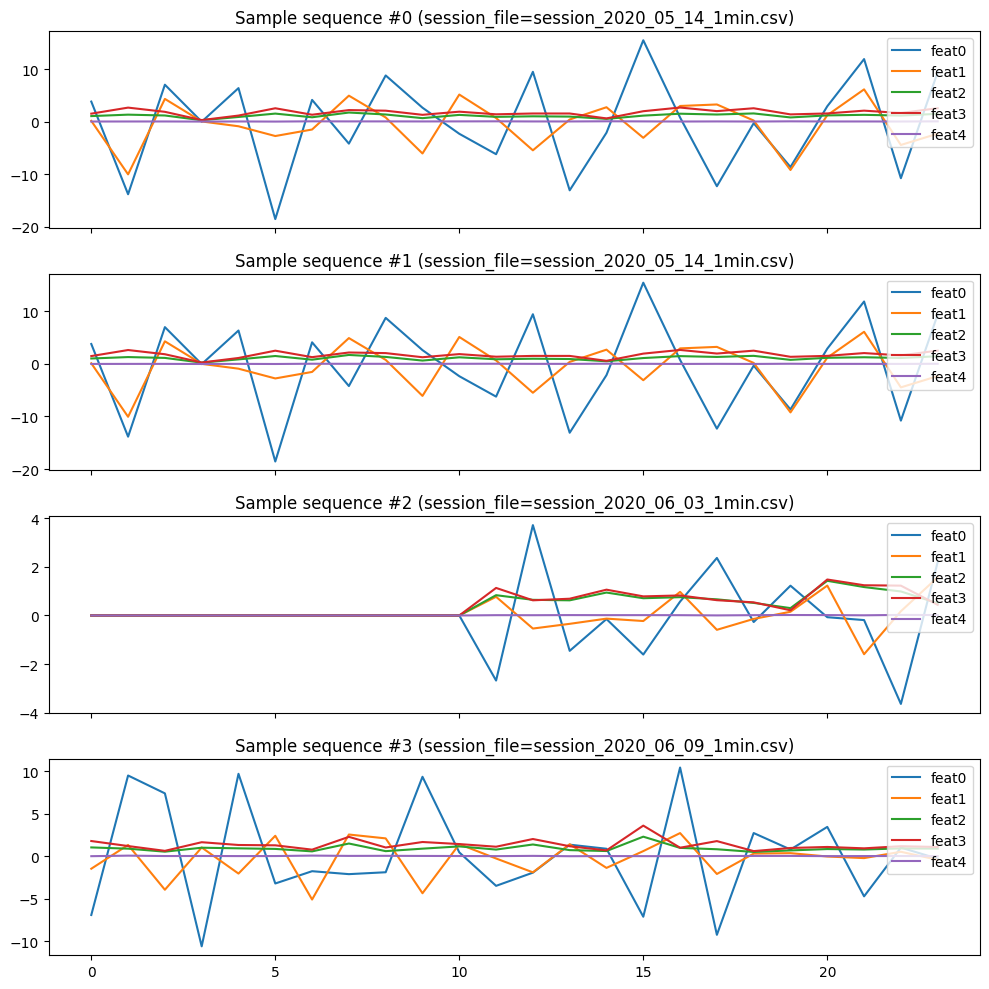

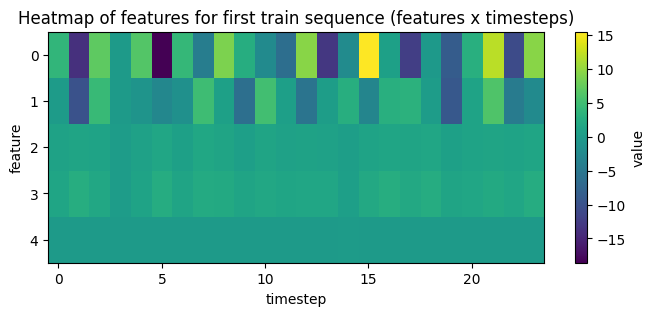

In [13]:
# ------------------
# EDA: Sequence shapes and sample visualizations
# ------------------
import matplotlib.pyplot as plt
import numpy as np

print('Stat shapes:')
print(' X1_train_stat', X1_train_stat.shape, ' X2_train_stat', X2_train_stat.shape)
print('Seq shapes:')
print(' X1_train_seq', X1_train_seq.shape, ' X2_train_seq', X2_train_seq.shape)

# Plot a few sample sequences (first 4) from X1_train_seq
n_plot = min(4, X1_train_seq.shape[0])
fig, axs = plt.subplots(n_plot, 1, figsize=(10, 2.5 * n_plot), sharex=True)
for i in range(n_plot):
    a = X1_train_seq[i]  # shape: (seq_len, feats)
    for f in range(a.shape[1]):
        axs[i].plot(a[:, f], label=f'feat{f}')
    axs[i].set_title(f'Sample sequence #{i} (session_file={X1_train.iloc[i].get("session_file", "?")})')
    axs[i].legend(loc='upper right')
plt.tight_layout()
plt.show()

# Quick heatmap of one sequence (seq_len x feats)
if X1_train_seq.shape[0] > 0:
    plt.figure(figsize=(8,3))
    plt.imshow(X1_train_seq[0].T, aspect='auto', cmap='viridis')
    plt.colorbar(label='value')
    plt.title('Heatmap of features for first train sequence (features x timesteps)')
    plt.xlabel('timestep')
    plt.ylabel('feature')
    plt.show()

In [15]:
# =========================
# Cell 1: Siamese Network Architecture (stat + temporal encoder)
# =========================
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Concatenate, Multiply, Dense, BatchNormalization, Dropout, Lambda, Conv1D, GlobalAveragePooling1D
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l1, l2, l1_l2

# Stat and temporal dims (from preprocessed arrays)
stat_dim = X1_train_stat.shape[1]
seq_len = X1_train_seq.shape[1]
seq_feat_dim = X1_train_seq.shape[2]

def create_encoder(stat_dim, seq_len, seq_feat_dim, embedding_dim=64, reg_type="l1", reg_strength=1e-3):
    if reg_type == "l1":
        reg = l1(reg_strength)
    elif reg_type == "l2":
        reg = l2(reg_strength)
    elif reg_type == "elasticnet":
        reg = l1_l2(l1=reg_strength, l2=reg_strength * 0.5)
    else:
        reg = None

    # statistical input branch
    stat_in = Input(shape=(stat_dim,), name='stat_input')
    s = Dense(128, activation='relu', kernel_regularizer=reg)(stat_in)
    s = BatchNormalization()(s)
    s = Dropout(0.2)(s)
    s = Dense(64, activation='relu', kernel_regularizer=reg)(s)

    # temporal input branch
    seq_in = Input(shape=(seq_len, seq_feat_dim), name='seq_input')
    t = Conv1D(32, kernel_size=3, padding='same', activation='relu')(seq_in)
    t = BatchNormalization()(t)
    t = Conv1D(64, kernel_size=3, padding='same', activation='relu')(t)
    t = BatchNormalization()(t)
    t = GlobalAveragePooling1D()(t)
    t = Dense(64, activation='relu')(t)

    # concat
    x = Concatenate()([s, t])
    x = Dense(embedding_dim, activation=None, kernel_regularizer=reg)(x)
    x = Lambda(lambda t: K.l2_normalize(t, axis=1))(x)
    return Model([stat_in, seq_in], x, name='encoder')

# Create shared encoder
encoder = create_encoder(stat_dim, seq_len, seq_feat_dim, embedding_dim=64, reg_type="l1", reg_strength=1e-3)

# Siamese Inputs
input_a_stat = Input(shape=(stat_dim,), name='input_a_stat')
input_a_seq = Input(shape=(seq_len, seq_feat_dim), name='input_a_seq')
input_b_stat = Input(shape=(stat_dim,), name='input_b_stat')
input_b_seq = Input(shape=(seq_len, seq_feat_dim), name='input_b_seq')

# Encode both inputs
encoded_a = encoder([input_a_stat, input_a_seq])
encoded_b = encoder([input_b_stat, input_b_seq])

# Merge embeddings: absolute difference + optional element-wise multiplication
abs_diff = Lambda(lambda t: K.abs(t[0] - t[1]))([encoded_a, encoded_b])
mul = Multiply()([encoded_a, encoded_b])
merge = Concatenate()([abs_diff, mul])

# Dense head
x = Dense(64, activation='relu')(merge)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

# Output layer
output = Dense(1, activation='sigmoid')(x)

# Build Siamese model
siamese_model = Model(inputs=[input_a_stat, input_a_seq, input_b_stat, input_b_seq], outputs=output)
siamese_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_a_stat        │ (None, 62)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_a_seq         │ (None, 24, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_b_stat        │ (None, 62)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_b_seq         │ (None, 24, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ (None, 64)        │     36,352 │ input_a_stat[0][… │
│ (Functional)        │                   │            │ input_a_seq[0][0… │
│                     │                   │            │ input_b_stat[0][… │
│                     │                   │            │ input_b_seq[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 64)        │          0 │ encoder[0][0],    │
│                     │                   │            │ encoder[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 64)        │          0 │ encoder[0][0],    │
│ (Multiply)          │                   │            │ encoder[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 128)       │          0 │ lambda_3[0][0],   │
│ (Concatenate)       │                   │            │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │      8,256 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_11[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 32)        │      2,080 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_12[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 1)         │         33 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 47,105 (184.00 KB)

 Trainable params: 46,465 (181.50 KB)

 Non-trainable params: 640 (2.50 KB)

In [16]:
import tensorflow as tf
from tensorflow.keras import backend as K

def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        eps = K.epsilon()
        y_pred = K.clip(y_pred, eps, 1. - eps)
        loss_pos = -alpha * (1 - y_pred)**gamma * K.log(y_pred)
        loss_neg = -(1 - alpha) * y_pred**gamma * K.log(1 - y_pred)
        return K.mean(y_true * loss_pos + (1 - y_true) * loss_neg)
    return focal_loss_fixed


In [17]:
# =========================
# Cell 2: Compilation (no class-weight; using balanced batching instead)
# =========================
from tensorflow.keras.metrics import AUC
import numpy as np

# NOTE: We previously used class weights to address imbalance. That is disabled
# because we will use balanced batching (equal pos/neg per batch) during training.
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

siamese_model.compile(
    optimizer=optimizer,
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=[AUC(name='auc'), 'Precision', 'Recall']
)


In [18]:
# --------------------------------------------------
# Runtime: ensure MLflow autologging is disabled if already loaded
# This handles the case where the notebook kernel previously imported mlflow
# and autologging patches remain active. It attempts to disable autologging
# and remove mlflow modules from sys.modules. Restarting the kernel is still
# the cleanest way to fully clear patched functions, but this helps in-session.
# --------------------------------------------------
import sys
if 'mlflow' in sys.modules:
    try:
        import mlflow
        # Attempt framework-specific disable first
        try:
            import mlflow.tensorflow
            mlflow.tensorflow.autolog(disable=True)
        except Exception:
            pass
        # Generic autolog disable (best-effort)
        try:
            mlflow.autolog(disable=True)
        except Exception:
            pass
        # Remove mlflow modules from sys.modules to avoid future inadvertent use
        for m in list(sys.modules.keys()):
            if m.startswith('mlflow'):
                try: del sys.modules[m]
                except Exception: pass
        print('MLflow detected: autologging disabled and mlflow modules removed from sys.modules.Consider restarting the kernel to fully clear any monkey-patches.')
    except Exception as e:
        print('Error while disabling MLflow autologging:', e)
else:
    print('No mlflow module detected in sys.modules')


No mlflow module detected in sys.modules


In [19]:
# =========================
# Cell 3: Training with EarlyStopping + Balanced Keras Sequence (temporal aware)
# (Temporarily reduced batch_size and epochs for a quick sanity run)
# =========================
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import Sequence
# MLflow removed from this notebook to avoid autologging conflicts with custom data feeders
import numpy as np

# Use EarlyStopping with patience in the 5-7 range and restore best weights
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

# Callback to record minority-class metrics per epoch (train & val)
class MinorityClassMetrics(tf.keras.callbacks.Callback):
    """Compute precision/recall/f1 for the minority class each epoch on train & val.
    
    Stores results in .history dict with keys:
      'train_prec','train_rec','train_f1','val_prec','val_rec','val_f1'
    """
    def __init__(self, train_data, val_data=None, minority_label=1):
        super().__init__()
        # Expect train_data and val_data to be tuples: (inputs_tuple, y_array)
        self.train_data = train_data
        self.val_data = val_data
        self.minority = minority_label
        self.history = {k: [] for k in ['train_prec','train_rec','train_f1','val_prec','val_rec','val_f1']}
    
    def _compute_metrics(self, y_true, y_pred):
        from sklearn.metrics import precision_recall_fscore_support
        try:
            p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, pos_label=self.minority, average='binary')
        except Exception:
            p, r, f = 0.0, 0.0, 0.0
        return float(p), float(r), float(f)
    
    def on_epoch_end(self, epoch, logs=None):
        # Train metrics
        try:
            X_train_inputs, y_train = self.train_data
            # X_train_inputs is a tuple matching model.inputs: (stat_a, seq_a, stat_b, seq_b)
            y_train_prob = self.model.predict(X_train_inputs, verbose=0)
            y_train_pred = (y_train_prob >= 0.5).astype(int).ravel()
            p,r,f = self._compute_metrics(np.asarray(y_train).ravel(), y_train_pred)
        except Exception:
            p,r,f = 0.0,0.0,0.0
        self.history['train_prec'].append(p)
        self.history['train_rec'].append(r)
        self.history['train_f1'].append(f)
        
        # Val metrics (if provided)
        if self.val_data is not None:
            try:
                X_val_inputs, y_val = self.val_data
                y_val_prob = self.model.predict(X_val_inputs, verbose=0)
                y_val_pred = (y_val_prob >= 0.5).astype(int).ravel()
                vp, vr, vf = self._compute_metrics(np.asarray(y_val).ravel(), y_val_pred)
            except Exception:
                vp, vr, vf = 0.0,0.0,0.0
            self.history['val_prec'].append(vp)
            self.history['val_rec'].append(vr)
            self.history['val_f1'].append(vf)
        else:
            # keep lengths aligned
            self.history['val_prec'].append(0.0)
            self.history['val_rec'].append(0.0)
            self.history['val_f1'].append(0.0)

# Instantiate the callback with TRAIN and VAL full data (used for epochwise metrics)
minority_cb = MinorityClassMetrics(
    train_data=((X1_train_stat.astype('float32'), X1_train_seq.astype('float32'), X2_train_stat.astype('float32'), X2_train_seq.astype('float32')), y_train.astype('int32')) ,
    val_data=((X1_val_stat.astype('float32'), X1_val_seq.astype('float32'), X2_val_stat.astype('float32'), X2_val_seq.astype('float32')), y_val.astype('int32')) ,
    minority_label=1,
 )

# ------------------
# Balanced Keras Sequence (temporal-aware)
# ------------------
class BalancedSequenceTemporal(Sequence):
    """Keras Sequence that yields balanced batches with half positives and half negatives,
    and returns inputs as a tuple matching model.inputs: (stat_a, seq_a, stat_b, seq_b)."""
    def __init__(self, X1_stat, X1_seq, X2_stat, X2_seq, y, batch_size=8, pos_label=1, seed=None):
        # convert to numpy arrays with explicit dtypes
        self.X1_stat = np.asarray(X1_stat).astype('float32')
        self.X2_stat = np.asarray(X2_stat).astype('float32')
        self.X1_seq = np.asarray(X1_seq).astype('float32')
        self.X2_seq = np.asarray(X2_seq).astype('float32')
        self.y = np.asarray(y).astype('int32').ravel()
        self.batch_size = int(batch_size)
        self.half = max(1, self.batch_size // 2)
        self.pos_idx = np.where(self.y == pos_label)[0]
        self.neg_idx = np.where(self.y != pos_label)[0]
        if len(self.pos_idx) == 0 or len(self.neg_idx) == 0:
            raise ValueError('Both positive and negative samples are required for BalancedSequenceTemporal')
        self.rng = np.random.default_rng(seed)
        # define number of steps per epoch
        self.steps = int(np.ceil(len(self.y) / float(self.batch_size)))
    
    def __len__(self):
        return self.steps
    
    def __getitem__(self, idx):
        # sample positives
        if len(self.pos_idx) >= self.half:
            pos_sample = self.rng.choice(self.pos_idx, size=self.half, replace=False)
        else:
            pos_sample = self.rng.choice(self.pos_idx, size=self.half, replace=True)
        # sample negatives
        if len(self.neg_idx) >= self.half:
            neg_sample = self.rng.choice(self.neg_idx, size=self.half, replace=False)
        else:
            neg_sample = self.rng.choice(self.neg_idx, size=self.half, replace=True)
        
        idxs = np.concatenate([pos_sample, neg_sample])
        self.rng.shuffle(idxs)
        
        stat_a = self.X1_stat[idxs]
        seq_a = self.X1_seq[idxs]
        stat_b = self.X2_stat[idxs]
        seq_b = self.X2_seq[idxs]
        yb = self.y[idxs]
        
        # return tuple matching model.inputs ordering (tuple, not list)
        return (stat_a, seq_a, stat_b, seq_b), yb
    
    def on_epoch_end(self):
        # optional: re-seed or reshuffle internal state each epoch
        self.rng = np.random.default_rng(None)

# ------------------
# Prepare Sequence and run a quick sanity fit (1 epoch)
# ------------------
batch_size = 8  # reduced for quick run
train_seq = BalancedSequenceTemporal(X1_train_stat, X1_train_seq, X2_train_stat, X2_train_seq, y_train, batch_size=batch_size, seed=42)

# Quick sanity training (reduced epochs; EarlyStopping will halt earlier if needed)
history = siamese_model.fit(
    train_seq,
    validation_data=((X1_val_stat.astype('float32'), X1_val_seq.astype('float32'), X2_val_stat.astype('float32'), X2_val_seq.astype('float32')), y_val.astype('int32')),
    epochs=50,
    callbacks=[early_stop, reduce_lr, minority_cb],
    verbose=2,
 )

d:\hack\impostor_detection\impostor_detection\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
524/524 - 19s - 36ms/step - Precision: 0.7299 - Recall: 0.5014 - auc: 0.7413 - loss: 1.9746 - val_Precision: 0.2667 - val_Recall: 0.2667 - val_auc: 0.7452 - val_loss: 1.6576 - learning_rate: 1.0000e-03
Epoch 2/50
524/524 - 4s - 7ms/step - Precision: 0.8666 - Recall: 0.6231 - auc: 0.8759 - loss: 1.4249 - val_Precision: 0.3529 - val_Recall: 0.4000 - val_auc: 0.8151 - val_loss: 1.1632 - learning_rate: 1.0000e-03
Epoch 3/50
524/524 - 4s - 7ms/step - Precision: 0.9186 - Recall: 0.7533 - auc: 0.9428 - loss: 0.9505 - val_Precision: 0.3529 - val_Recall: 0.4000 - val_auc: 0.7389 - val_loss: 0.7643 - learning_rate: 1.0000e-03
Epoch 4/50
524/524 - 3s - 6ms/step - Precision: 0.9274 - Recall: 0.8101 - auc: 0.9597 - loss: 0.5838 - val_Precision: 0.2069 - val_Recall: 0.4000 - val_auc: 0.7333 - val_loss: 0.4743 - learning_rate: 1.0000e-03
Epoch 5/50
524/524 - 4s - 8ms/step - Precision: 0.9471 - Recall: 0.8540 - auc: 0.9697 - loss: 0.3405 - val_Precision: 0.2222 - val_Recall: 0.2667 - val_au

In [39]:
# =========================
# Extract Embeddings using the trained encoder
# =========================
import numpy as np
import pandas as pd

print("Extracting embeddings from trained encoder...")
    
# Encode train data (1min and 3min)
emb_train_1min = encoder.predict([X1_train_stat, X1_train_seq], verbose=0)
emb_train_3min = encoder.predict([X2_train_stat, X2_train_seq], verbose=0)

# Encode val data
emb_val_1min = encoder.predict([X1_val_stat, X1_val_seq], verbose=0)
emb_val_3min = encoder.predict([X2_val_stat, X2_val_seq], verbose=0)

# Encode test data
emb_test_1min = encoder.predict([X1_test_stat, X1_test_seq], verbose=0)
emb_test_3min = encoder.predict([X2_test_stat, X2_test_seq], verbose=0)

print(f"Train embeddings: 1min={emb_train_1min.shape}, 3min={emb_train_3min.shape}")
print(f"Val embeddings: 1min={emb_val_1min.shape}, 3min={emb_val_3min.shape}")
print(f"Test embeddings: 1min={emb_test_1min.shape}, 3min={emb_test_3min.shape}")

# Store embeddings for later use
embeddings_dict = {
    'train_1min': emb_train_1min,
    'train_3min': emb_train_3min,
    'val_1min': emb_val_1min,
    'val_3min': emb_val_3min,
    'test_1min': emb_test_1min,
    'test_3min': emb_test_3min
}


Extracting embeddings from trained encoder...
Train embeddings: 1min=(4188, 64), 3min=(4188, 64)
Val embeddings: 1min=(225, 64), 3min=(225, 64)
Test embeddings: 1min=(256, 64), 3min=(256, 64)


In [40]:
# =========================
# Prepare embeddings with labels and subsample impostor cases
# =========================
import numpy as np
import pandas as pd

# Combine all embeddings with metadata
def prepare_embedding_data(emb_dict, X1_dfs, X2_dfs, y_arrays, split_names):
    """Combine embeddings from 1min and 3min sessions with labels"""
    all_data = []
    
    for split_name, X1_df, X2_df, y in zip(split_names, X1_dfs, X2_dfs, y_arrays):
        # 1min sessions (X1)
        emb_1min = emb_dict[f'{split_name}_1min']
        for i in range(len(emb_1min)):
            all_data.append({
                'embedding': emb_1min[i],
                'user_id': X1_df.iloc[i].get('user_id', '?'),
                'session_type': '1min',
                'split': split_name,
                'idx': i
            })
        
        # 3min sessions (X2)
        emb_3min = emb_dict[f'{split_name}_3min']
        for i in range(len(emb_3min)):
            all_data.append({
                'embedding': emb_3min[i],
                'user_id': X2_df.iloc[i].get('user_id', '?'),
                'session_type': '3min',
                'split': split_name,
                'idx': i
            })
    
    return pd.DataFrame(all_data)

# Prepare full dataset
print("Preparing embedding data with labels...")
emb_df = prepare_embedding_data(
    embeddings_dict,
    [X1_train, X1_val, X1_test],
    [X2_train, X2_val, X2_test],
    [y_train, y_val, y_test],
    ['train', 'val', 'test']
)

print(f"Total embeddings: {len(emb_df)}")
print(f"Users: {emb_df['user_id'].nunique()}")
print(f"Session types: {emb_df['session_type'].value_counts().to_dict()}")
print(f"Splits: {emb_df['split'].value_counts().to_dict()}")

# Note: No subsampling needed - each embedding represents a unique session
# Visualizations will show natural clustering of genuine users
print(f"\nPrepared {len(emb_df)} session embeddings for visualization")
print("Sessions will cluster naturally based on user identity")


Preparing embedding data with labels...
Total embeddings: 9338
Users: 120
Session types: {'1min': 4669, '3min': 4669}
Splits: {'train': 8376, 'test': 512, 'val': 450}

Prepared 9338 session embeddings for visualization
Sessions will cluster naturally based on user identity


In [41]:
# =========================
# Apply t-SNE dimensionality reduction
# =========================
from sklearn.manifold import TSNE
import numpy as np

print("Applying t-SNE (this may take a few minutes)...")

# Extract embedding matrix
X_emb = np.stack(emb_df['embedding'].values)
print(f"Embedding shape: {X_emb.shape}")

# Apply t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    random_state=42,
    verbose=1
)

X_tsne = tsne.fit_transform(X_emb)
print(f"t-SNE complete. Output shape: {X_tsne.shape}")

# Add t-SNE coordinates to dataframe
emb_df['tsne_x'] = X_tsne[:, 0]
emb_df['tsne_y'] = X_tsne[:, 1]

print("t-SNE coordinates added to emb_df")


Applying t-SNE (this may take a few minutes)...
Embedding shape: (9338, 64)
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 9338 samples in 0.004s...
[t-SNE] Computed neighbors for 9338 samples in 0.631s...
[t-SNE] Computed conditional probabilities for sample 1000 / 9338
[t-SNE] Computed conditional probabilities for sample 2000 / 9338
[t-SNE] Computed conditional probabilities for sample 3000 / 9338
[t-SNE] Computed conditional probabilities for sample 4000 / 9338
[t-SNE] Computed conditional probabilities for sample 5000 / 9338
[t-SNE] Computed conditional probabilities for sample 6000 / 9338
[t-SNE] Computed conditional probabilities for sample 7000 / 9338
[t-SNE] Computed conditional probabilities for sample 8000 / 9338
[t-SNE] Computed conditional probabilities for sample 9000 / 9338
[t-SNE] Computed conditional probabilities for sample 9338 / 9338
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 33.290733
[t-SNE] KL diver

In [42]:
# =========================
# Apply UMAP dimensionality reduction (optional - requires umap-learn package)
# =========================
import numpy as np

try:
    import umap
    
    print("Applying UMAP...")
    
    # Extract embedding matrix
    X_emb = np.stack(emb_df['embedding'].values)
    
    # Apply UMAP with random initialization to avoid spectral eigengap issues
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=2,
        metric='cosine',
        init='random',
        random_state=42,
        verbose=True
    )
    
    X_umap = reducer.fit_transform(X_emb)
    print(f"UMAP complete. Output shape: {X_umap.shape}")
    
    # Add UMAP coordinates to dataframe
    emb_df['umap_x'] = X_umap[:, 0]
    emb_df['umap_y'] = X_umap[:, 1]
    
    print("UMAP coordinates added to emb_df")
    
except ImportError:
    print("UMAP not installed. Skipping UMAP reduction.")
    print("To install: pip install umap-learn")
    emb_df['umap_x'] = np.nan
    emb_df['umap_y'] = np.nan


Applying UMAP...
UMAP(angular_rp_forest=True, init='random', metric='cosine', n_jobs=1, random_state=42, verbose=True)
Mon Feb 16 13:33:26 2026 Construct fuzzy simplicial set
Mon Feb 16 13:33:26 2026 Finding Nearest Neighbors
Mon Feb 16 13:33:26 2026 Building RP forest with 10 trees
Mon Feb 16 13:33:27 2026 NN descent for 13 iterations


d:\hack\impostor_detection\impostor_detection\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



	 1  /  13
	 2  /  13
	Stopping threshold met -- exiting after 2 iterations
Mon Feb 16 13:33:27 2026 Finished Nearest Neighbor Search
Mon Feb 16 13:33:27 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon Feb 16 13:34:13 2026 Finished embedding
UMAP complete. Output shape: (9338, 2)
UMAP coordinates added to emb_df



Creating t-SNE visualization for TRAIN split (8376 sessions)...


C:\Users\Soumyadeep\AppData\Local\Temp\ipykernel_1592\3980862557.py:49: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



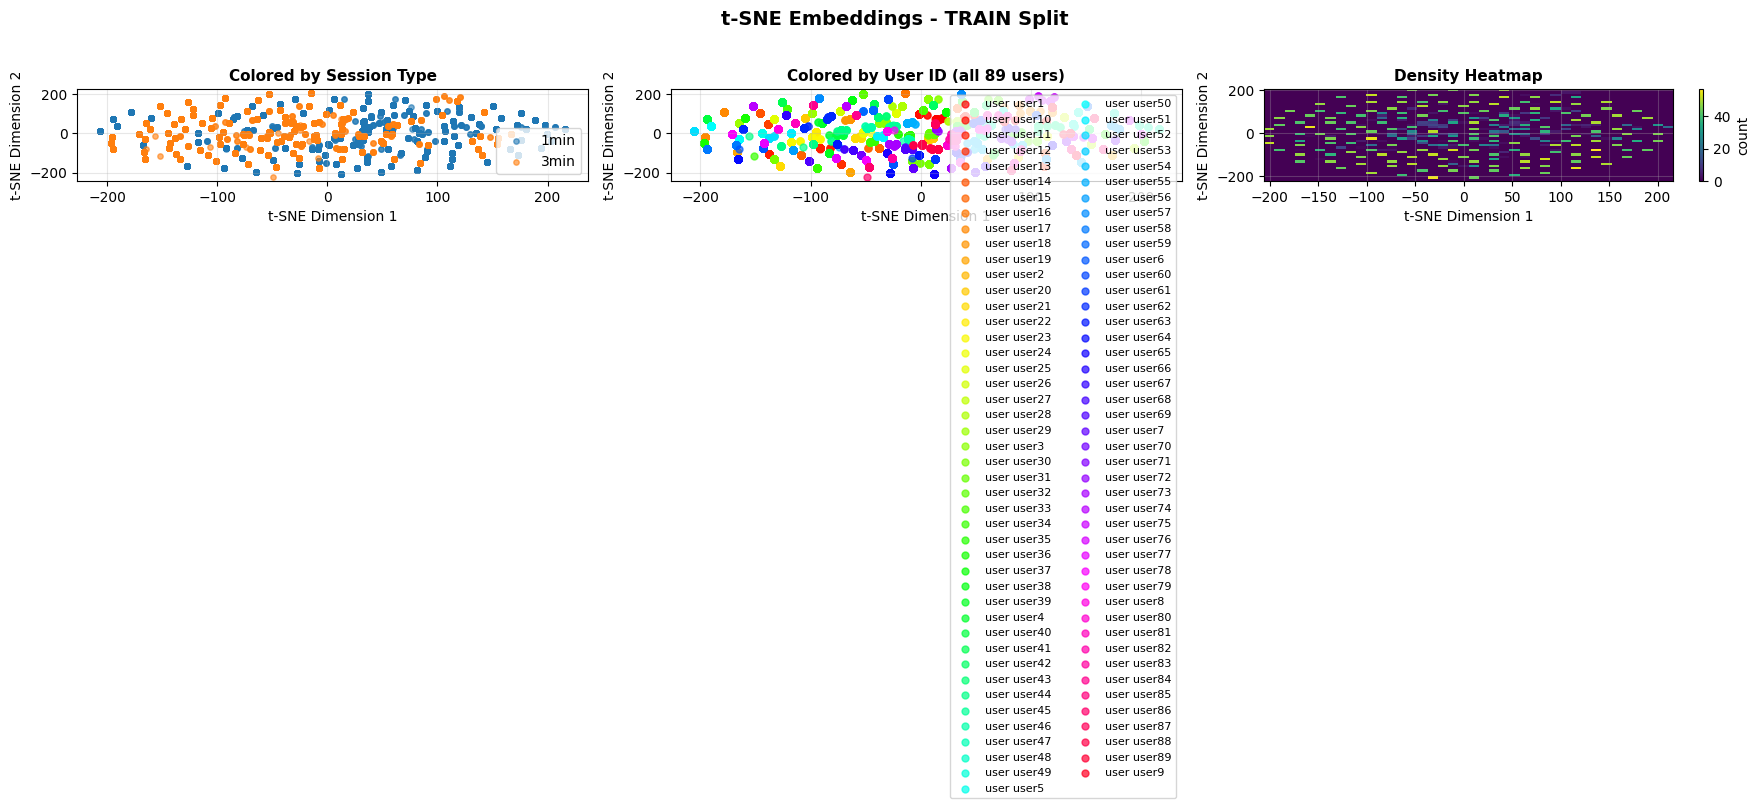


Creating t-SNE visualization for VAL split (450 sessions)...


C:\Users\Soumyadeep\AppData\Local\Temp\ipykernel_1592\3980862557.py:47: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



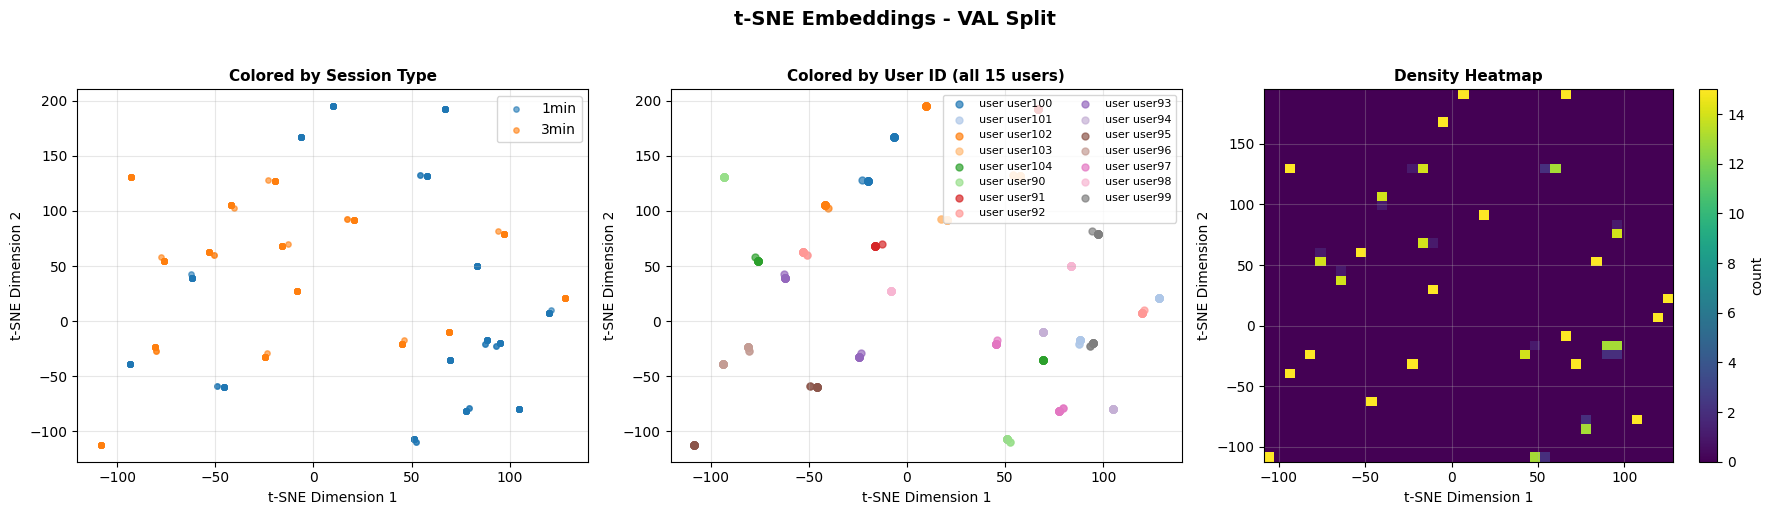


Creating t-SNE visualization for TEST split (512 sessions)...


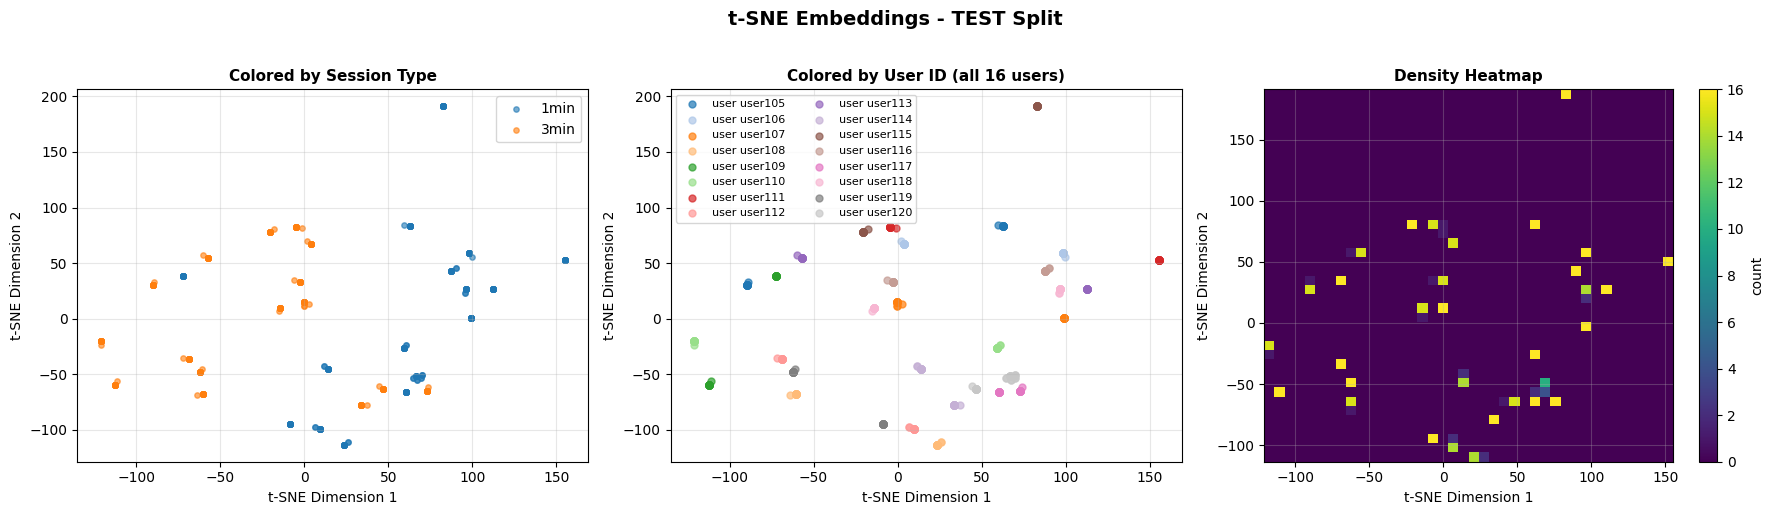


t-SNE visualizations complete for all splits!
Total sessions visualized: 9338


In [43]:
# =========================
# Visualize t-SNE embeddings (static plots) - Separate plots for each split
# =========================
import matplotlib.pyplot as plt
import numpy as np

# Create separate visualization for each split
for split_name in ['train', 'val', 'test']:
    split_df = emb_df[emb_df['split'] == split_name].copy()
    
    if len(split_df) == 0:
        print(f"No data for {split_name} split, skipping...")
        continue
    
    print(f"\nCreating t-SNE visualization for {split_name.upper()} split ({len(split_df)} sessions)...")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f't-SNE Embeddings - {split_name.upper()} Split', fontsize=14, fontweight='bold', y=1.02)
    
    # Plot 1: Color by session type (1min vs 3min)
    ax = axes[0]
    for stype in ['1min', '3min']:
        mask = split_df['session_type'] == stype
        if mask.any():
            ax.scatter(
                split_df.loc[mask, 'tsne_x'],
                split_df.loc[mask, 'tsne_y'],
                alpha=0.6,
                s=15,
                label=stype
            )
    ax.set_title('Colored by Session Type', fontsize=11, fontweight='bold')
    ax.set_xlabel('t-SNE Dimension 1')
    ax.set_ylabel('t-SNE Dimension 2')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Plot 2: Color by user_id (all users in split)
    ax = axes[1]
    all_users = sorted(split_df['user_id'].unique())
    n_users = len(all_users)
    
    # Choose colormap based on number of users
    if n_users <= 10:
        cmap = plt.cm.get_cmap('tab10')
    elif n_users <= 20:
        cmap = plt.cm.get_cmap('tab20')
    else:
        cmap = plt.cm.get_cmap('hsv')
    
    # Plot all users with distinct colors
    for i, user in enumerate(all_users):
        mask = split_df['user_id'] == user
        if mask.any():
            color_idx = i / n_users if n_users > 20 else i
            ax.scatter(
                split_df.loc[mask, 'tsne_x'],
                split_df.loc[mask, 'tsne_y'],
                alpha=0.7,
                s=25,
                label=f'user {user}',
                c=[cmap(color_idx)]
            )
    ax.set_title(f'Colored by User ID (all {n_users} users)', fontsize=11, fontweight='bold')
    ax.set_xlabel('t-SNE Dimension 1')
    ax.set_ylabel('t-SNE Dimension 2')
    ax.legend(fontsize=8, loc='best', ncol=2)
    ax.grid(alpha=0.3)
    
    # Plot 3: Density heatmap
    ax = axes[2]
    h = ax.hist2d(
        split_df['tsne_x'],
        split_df['tsne_y'],
        bins=40,
        cmap='viridis'
    )
    plt.colorbar(h[3], ax=ax, label='count')
    ax.set_title('Density Heatmap', fontsize=11, fontweight='bold')
    ax.set_xlabel('t-SNE Dimension 1')
    ax.set_ylabel('t-SNE Dimension 2')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*50)
print("t-SNE visualizations complete for all splits!")
print(f"Total sessions visualized: {len(emb_df)}")
print("="*50)



Creating UMAP visualization for TRAIN split (8376 sessions)...


C:\Users\Soumyadeep\AppData\Local\Temp\ipykernel_1592\2692932838.py:50: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



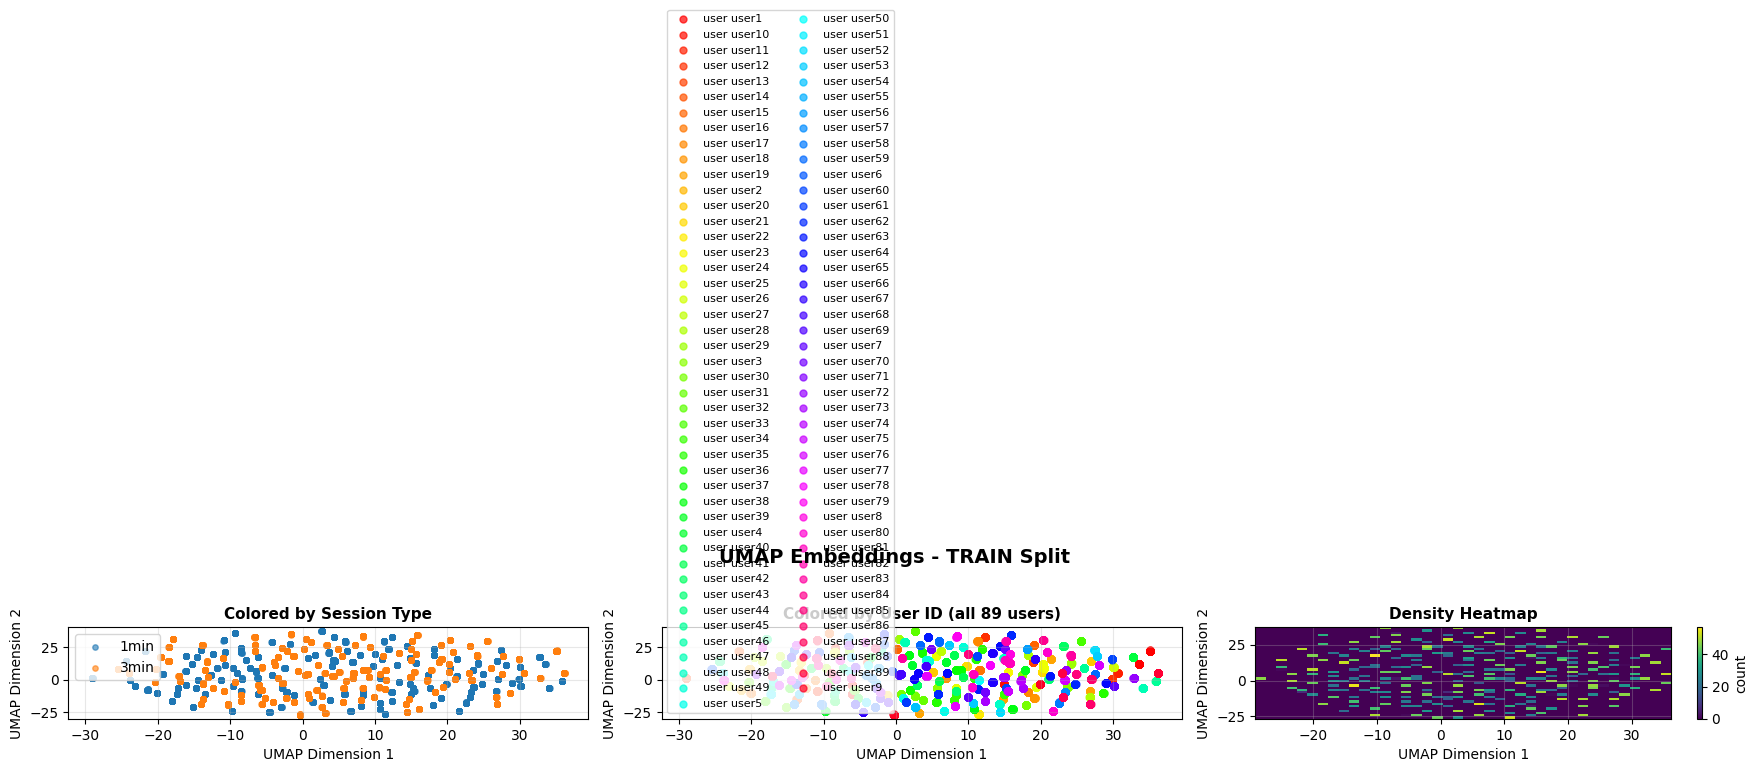


Creating UMAP visualization for VAL split (450 sessions)...


C:\Users\Soumyadeep\AppData\Local\Temp\ipykernel_1592\2692932838.py:48: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



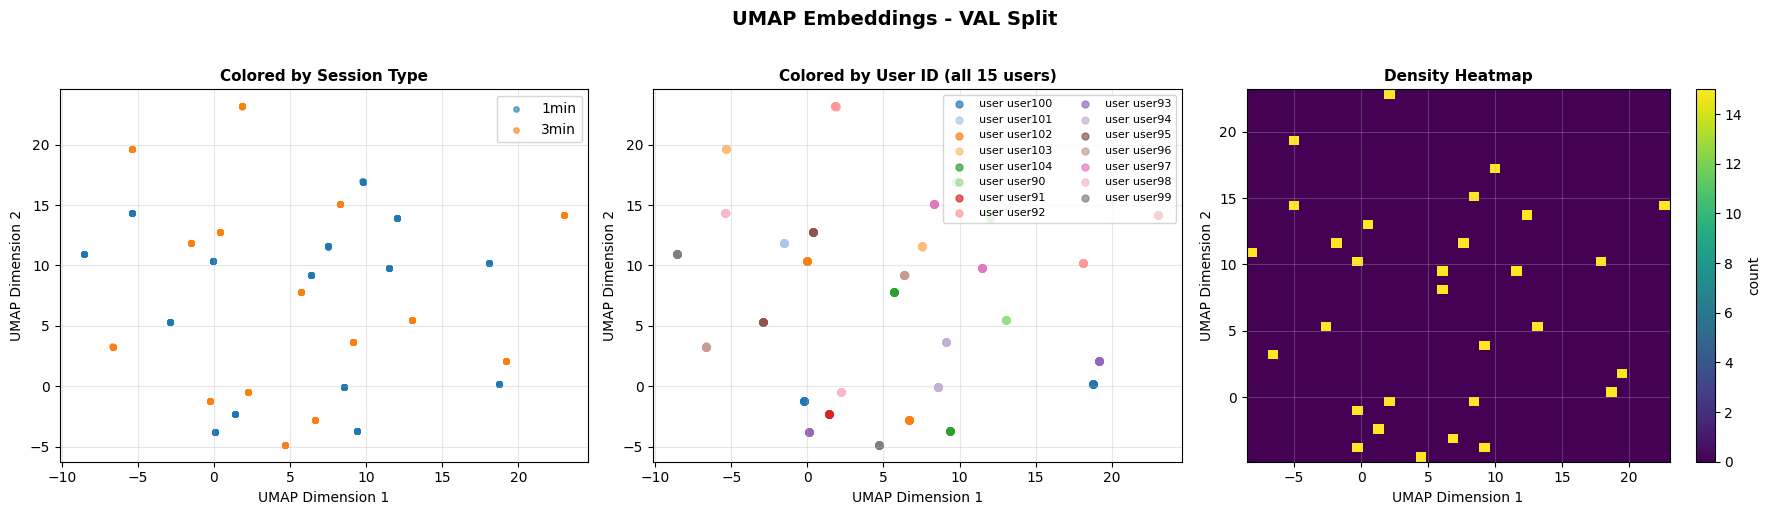


Creating UMAP visualization for TEST split (512 sessions)...


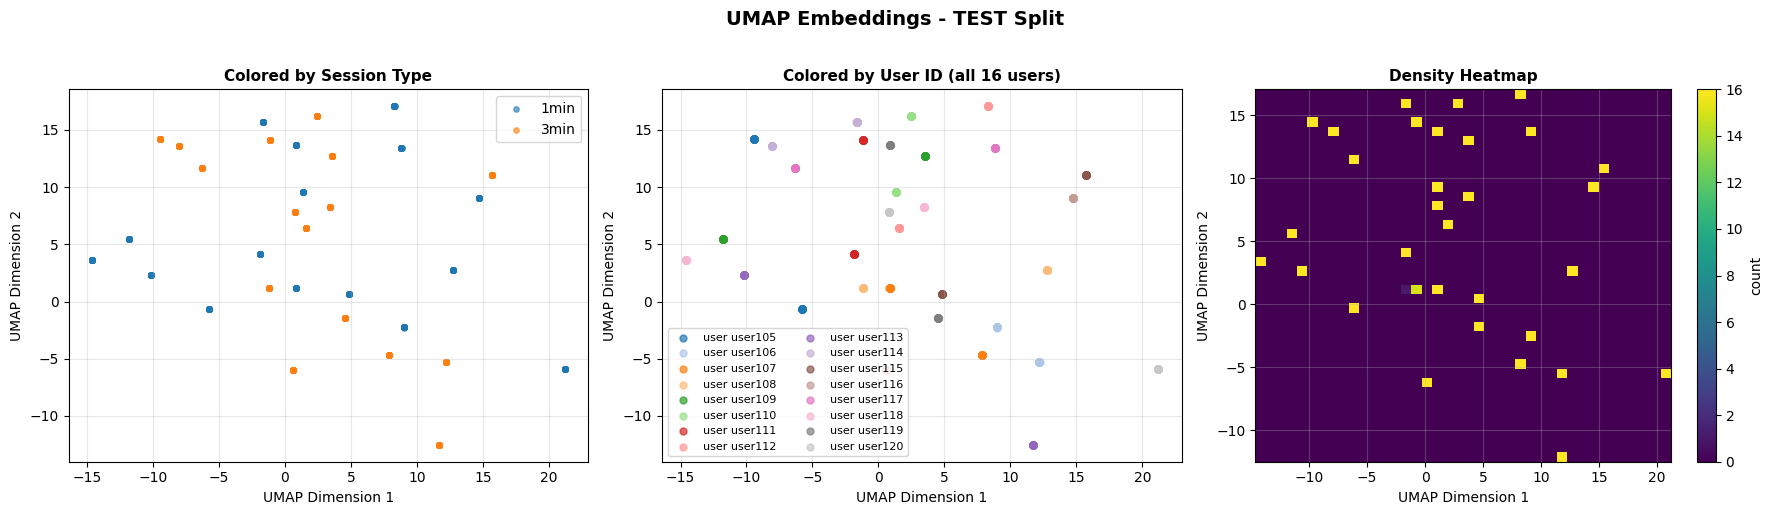


UMAP visualizations complete for all splits!


In [44]:
# =========================
# Visualize UMAP embeddings (if available) - Separate plots for each split
# =========================
import matplotlib.pyplot as plt
import numpy as np

if not emb_df['umap_x'].isna().all():
    # Create separate visualization for each split
    for split_name in ['train', 'val', 'test']:
        split_df = emb_df[emb_df['split'] == split_name].copy()
        
        if len(split_df) == 0:
            print(f"No data for {split_name} split, skipping...")
            continue
        
        print(f"\nCreating UMAP visualization for {split_name.upper()} split ({len(split_df)} sessions)...")
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'UMAP Embeddings - {split_name.upper()} Split', fontsize=14, fontweight='bold', y=1.02)
        
        # Plot 1: Color by session type
        ax = axes[0]
        for stype in ['1min', '3min']:
            mask = split_df['session_type'] == stype
            if mask.any():
                ax.scatter(
                    split_df.loc[mask, 'umap_x'],
                    split_df.loc[mask, 'umap_y'],
                    alpha=0.6,
                    s=15,
                    label=stype
                )
        ax.set_title('Colored by Session Type', fontsize=11, fontweight='bold')
        ax.set_xlabel('UMAP Dimension 1')
        ax.set_ylabel('UMAP Dimension 2')
        ax.legend()
        ax.grid(alpha=0.3)
        
        # Plot 2: Color by user_id (all users in split)
        ax = axes[1]
        all_users = sorted(split_df['user_id'].unique())
        n_users = len(all_users)
        
        # Choose colormap based on number of users
        if n_users <= 10:
            cmap = plt.cm.get_cmap('tab10')
        elif n_users <= 20:
            cmap = plt.cm.get_cmap('tab20')
        else:
            cmap = plt.cm.get_cmap('hsv')
        
        # Plot all users with distinct colors
        for i, user in enumerate(all_users):
            mask = split_df['user_id'] == user
            if mask.any():
                color_idx = i / n_users if n_users > 20 else i
                ax.scatter(
                    split_df.loc[mask, 'umap_x'],
                    split_df.loc[mask, 'umap_y'],
                    alpha=0.7,
                    s=25,
                    label=f'user {user}',
                    c=[cmap(color_idx)]
                )
        ax.set_title(f'Colored by User ID (all {n_users} users)', fontsize=11, fontweight='bold')
        ax.set_xlabel('UMAP Dimension 1')
        ax.set_ylabel('UMAP Dimension 2')
        ax.legend(fontsize=8, loc='best', ncol=2)
        ax.grid(alpha=0.3)
        
        # Plot 3: Density plot
        ax = axes[2]
        h = ax.hist2d(
            split_df['umap_x'],
            split_df['umap_y'],
            bins=40,
            cmap='viridis'
        )
        plt.colorbar(h[3], ax=ax, label='count')
        ax.set_title('Density Heatmap', fontsize=11, fontweight='bold')
        ax.set_xlabel('UMAP Dimension 1')
        ax.set_ylabel('UMAP Dimension 2')
        ax.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    print("\n" + "="*50)
    print("UMAP visualizations complete for all splits!")
    print("="*50)
else:
    print("UMAP coordinates not available. Skipping UMAP visualization.")
    print("Run the UMAP cell first or install umap-learn: pip install umap-learn")


In [45]:
# =========================
# Interactive Plotly visualization (optional) - Separate plots for each split
# =========================
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    
    print("Creating interactive visualizations with Plotly...")
    
    # Prepare hover text
    emb_df['hover_text'] = (
        'User: ' + emb_df['user_id'].astype(str) + '<br>' +
        'Type: ' + emb_df['session_type'] + '<br>' +
        'Split: ' + emb_df['split']
    )
    
    # Create separate interactive plots for each split (t-SNE)
    for split_name in ['train', 'val', 'test']:
        split_df = emb_df[emb_df['split'] == split_name].copy()
        
        if len(split_df) == 0:
            continue
        
        print(f"\nCreating interactive t-SNE plot for {split_name.upper()} split...")
        
        # Create interactive plot colored by user_id
        fig = px.scatter(
            split_df,
            x='tsne_x',
            y='tsne_y',
            color='user_id',
            symbol='session_type',
            hover_data=['user_id', 'session_type', 'split'],
            title=f'Interactive t-SNE Embedding - {split_name.upper()} Split (hover for details)',
            labels={'tsne_x': 't-SNE Dimension 1', 'tsne_y': 't-SNE Dimension 2'},
            width=900,
            height=700,
            opacity=0.6
        )
        
        fig.update_traces(marker=dict(size=6))
        fig.update_layout(
            legend=dict(
                itemsizing='constant',
                font=dict(size=8)
            )
        )
        
        fig.show()
    
    # If UMAP is available, create UMAP plots too
    if not emb_df['umap_x'].isna().all():
        print("\nCreating interactive UMAP plots...")
        
        for split_name in ['train', 'val', 'test']:
            split_df = emb_df[emb_df['split'] == split_name].copy()
            
            if len(split_df) == 0:
                continue
            
            print(f"  - {split_name.upper()} split...")
            
            fig_umap = px.scatter(
                split_df,
                x='umap_x',
                y='umap_y',
                color='user_id',
                symbol='session_type',
                hover_data=['user_id', 'session_type', 'split'],
                title=f'Interactive UMAP Embedding - {split_name.upper()} Split (hover for details)',
                labels={'umap_x': 'UMAP Dimension 1', 'umap_y': 'UMAP Dimension 2'},
                width=900,
                height=700,
                opacity=0.6
            )
            
            fig_umap.update_traces(marker=dict(size=6))
            fig_umap.update_layout(
                legend=dict(
                    itemsizing='constant',
                    font=dict(size=8)
                )
            )
            
            fig_umap.show()
    
    print("\n" + "="*50)
    print("Interactive visualizations complete for all splits!")
    print("Tip: Use the pan/zoom tools in the plot toolbar to explore clusters")
    print("="*50)
    
except ImportError:
    print("Plotly not installed. Skipping interactive visualizations.")
    print("To install: pip install plotly")


Creating interactive visualizations with Plotly...

Creating interactive t-SNE plot for TRAIN split...



Creating interactive t-SNE plot for VAL split...



Creating interactive t-SNE plot for TEST split...



Creating interactive UMAP plots...
  - TRAIN split...


  - VAL split...


  - TEST split...



Interactive visualizations complete for all splits!
Tip: Use the pan/zoom tools in the plot toolbar to explore clusters


In [46]:
# =========================
# Save embeddings and visualizations to disk
# =========================
import os
from pathlib import Path
from datetime import datetime

# Create output directory
output_dir = Path(PROCESSED_PATH) / 'embeddings'
output_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save embeddings dataframe (without the embedding arrays to save space)
emb_df_save = emb_df.drop(columns=['embedding']).copy()
emb_path = output_dir / f'embeddings_tsne_umap_{timestamp}.csv'
emb_df_save.to_csv(emb_path, index=False)
print(f"Saved embedding coordinates to: {emb_path}")

# Save full embedding arrays as numpy file (for later use)
emb_arrays_path = output_dir / f'embedding_vectors_{timestamp}.npz'
np.savez_compressed(
    emb_arrays_path,
    train_1min=embeddings_dict['train_1min'],
    train_3min=embeddings_dict['train_3min'],
    val_1min=embeddings_dict['val_1min'],
    val_3min=embeddings_dict['val_3min'],
    test_1min=embeddings_dict['test_1min'],
    test_3min=embeddings_dict['test_3min']
)
print(f"Saved embedding vectors to: {emb_arrays_path}")

# Save the encoder model separately (if needed for later inference)
encoder_path = output_dir / f'encoder_model_{timestamp}.keras'
encoder.save(encoder_path)
print(f"Saved encoder model to: {encoder_path}")

print(f"\nAll artifacts saved to: {output_dir}")
print("Summary:")
print(f"  - Embedding coordinates (CSV): {emb_path.name}")
print(f"  - Full embedding vectors (NPZ): {emb_arrays_path.name}")
print(f"  - Encoder model (Keras): {encoder_path.name}")


Saved embedding coordinates to: D:\hack\impostor_detection\impostor_detection\data\processed\embeddings\embeddings_tsne_umap_20260216_133428.csv
Saved embedding vectors to: D:\hack\impostor_detection\impostor_detection\data\processed\embeddings\embedding_vectors_20260216_133428.npz
Saved encoder model to: D:\hack\impostor_detection\impostor_detection\data\processed\embeddings\encoder_model_20260216_133428.keras

All artifacts saved to: D:\hack\impostor_detection\impostor_detection\data\processed\embeddings
Summary:
  - Embedding coordinates (CSV): embeddings_tsne_umap_20260216_133428.csv
  - Full embedding vectors (NPZ): embedding_vectors_20260216_133428.npz
  - Encoder model (Keras): encoder_model_20260216_133428.keras


Creating publication-quality plot for 16 test users...


C:\Users\Soumyadeep\AppData\Local\Temp\ipykernel_1592\3857460771.py:21: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



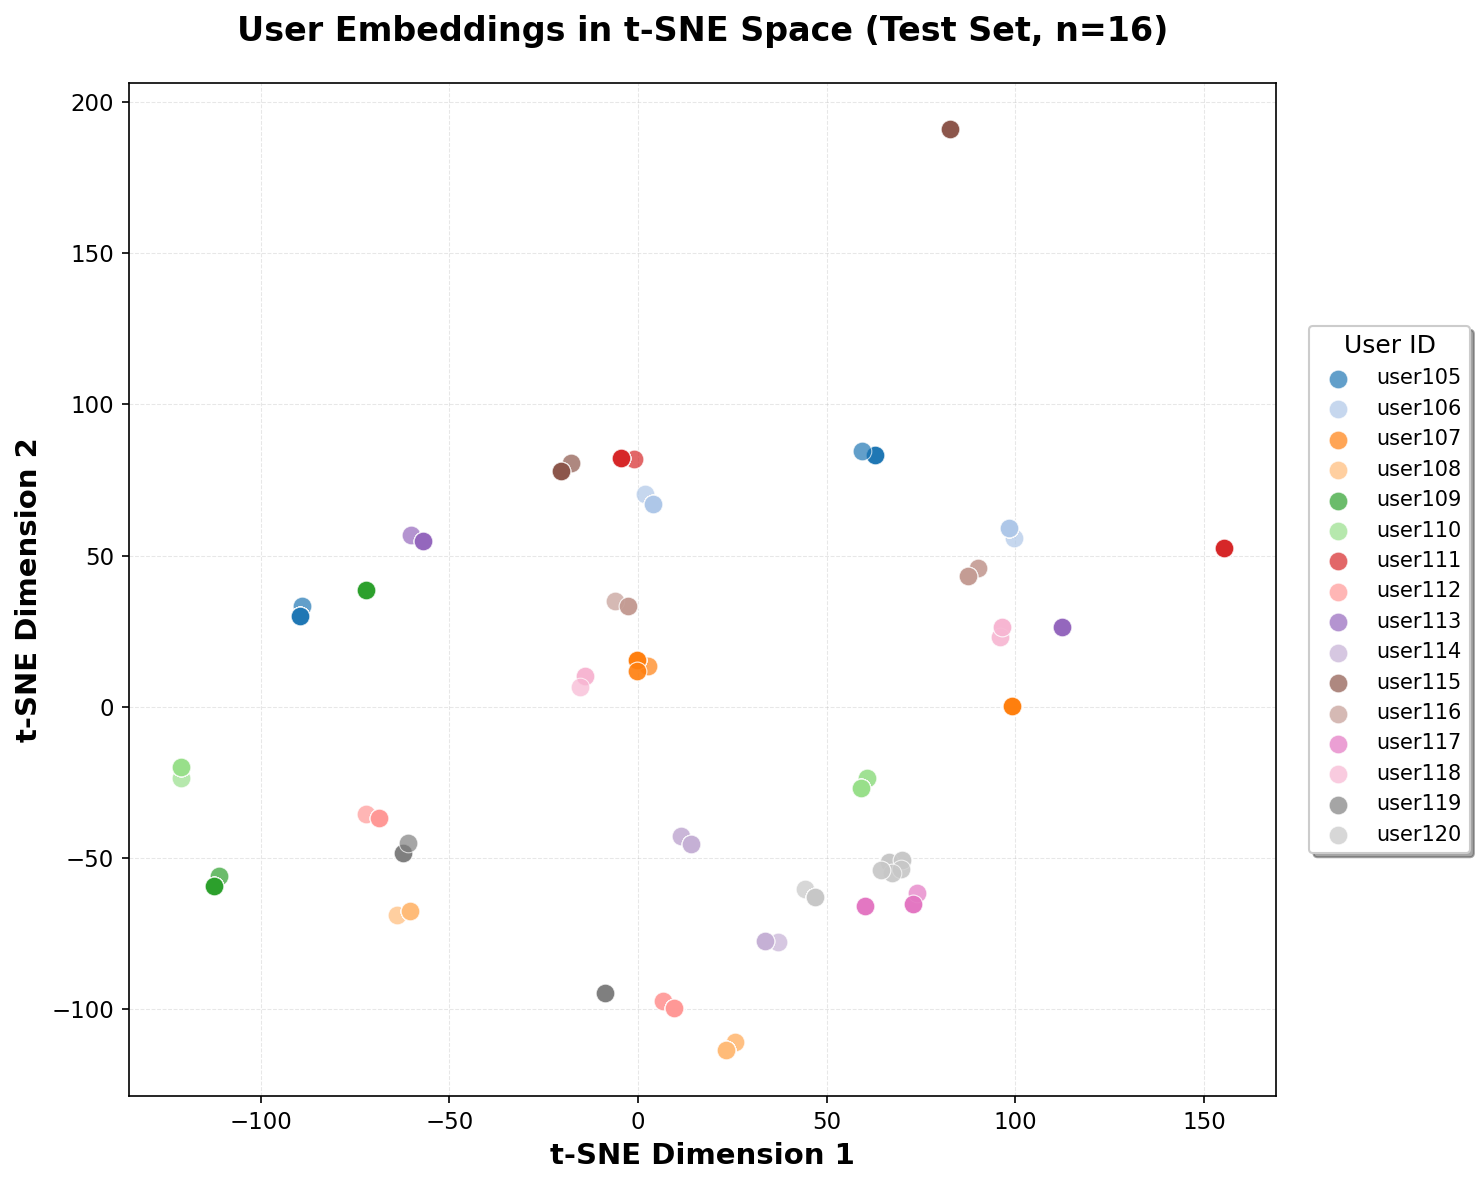


Publication-quality plot created successfully!
Total test sessions plotted: 512


In [47]:
# =========================
# Publication-Quality Plot: t-SNE Embeddings for Test Users
# =========================
import matplotlib.pyplot as plt
import numpy as np

# Filter for test split only
test_df = emb_df[emb_df['split'] == 'test'].copy()
all_users = sorted(test_df['user_id'].unique())
n_users = len(all_users)

print(f"Creating publication-quality plot for {n_users} test users...")

# Create figure with publication-quality settings
fig, ax = plt.subplots(figsize=(10, 8), dpi=150)

# Choose colormap based on number of users
if n_users <= 10:
    cmap = plt.cm.get_cmap('tab10')
elif n_users <= 20:
    cmap = plt.cm.get_cmap('tab20')
else:
    cmap = plt.cm.get_cmap('hsv')

# Plot each user with distinct colors
for i, user in enumerate(all_users):
    mask = test_df['user_id'] == user
    if mask.any():
        color_idx = i / n_users if n_users > 20 else i
        ax.scatter(
            test_df.loc[mask, 'tsne_x'],
            test_df.loc[mask, 'tsne_y'],
            alpha=0.7,
            s=80,
            label=f'{user}',
            c=[cmap(color_idx)],
            edgecolors='white',
            linewidth=0.5
        )

# Set labels and title with proper formatting
ax.set_xlabel('t-SNE Dimension 1', fontsize=14, fontweight='bold')
ax.set_ylabel('t-SNE Dimension 2', fontsize=14, fontweight='bold')
ax.set_title(f'User Embeddings in t-SNE Space (Test Set, n={n_users})', 
             fontsize=16, fontweight='bold', pad=20)

# Configure legend
ax.legend(
    title='User ID',
    title_fontsize=12,
    fontsize=10,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    fancybox=True,
    shadow=True,
    ncol=1
)

# Grid and styling
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
ax.tick_params(axis='both', which='major', labelsize=11)

# Tight layout to prevent label cutoff
plt.tight_layout()
plt.show()

print("\nPublication-quality plot created successfully!")
print(f"Total test sessions plotted: {len(test_df)}")

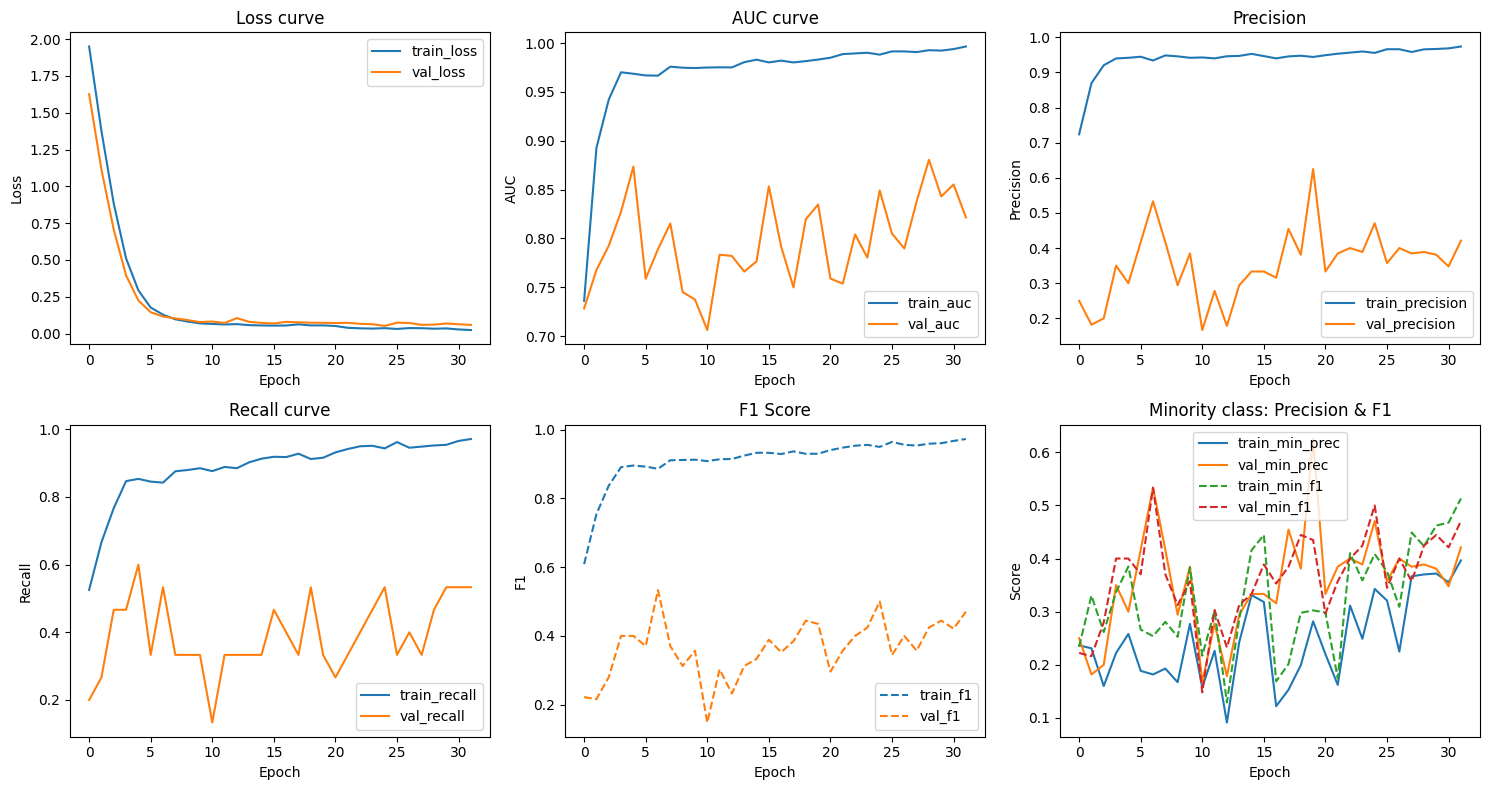

In [22]:
# =========================
# Cell 4: Plot Training Curves
# =========================
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15,8))

# helper to robustly find a metric key in history.history (handles case/val_ prefixes)
def _find_key(hist, base_name):
    base = base_name.lower()
    keys = list(hist.keys())
    # exact match (case-insensitive)
    for k in keys:
        if k.lower() == base:
            return k
    # val_ exact
    for k in keys:
        if k.lower() == f"val_{base}":
            return k
    # endswith match
    for k in keys:
        if k.lower().endswith(base):
            return k
    # contains
    for k in keys:
        if base in k.lower():
            return k
    return None

# find precision / recall keys for train & val
p_key = _find_key(history.history, 'precision')
r_key = _find_key(history.history, 'recall')
val_p_key = _find_key(history.history, 'val_precision') or (_find_key(history.history, 'precision') and f"val_{_find_key(history.history, 'precision')}")
val_r_key = _find_key(history.history, 'val_recall') or (_find_key(history.history, 'recall') and f"val_{_find_key(history.history, 'recall')}")

# fallback: try common Keras names if earlier lookup failed
if p_key is None:
    for candidate in ['Precision', 'precision']:
        if candidate in history.history:
            p_key = candidate
if r_key is None:
    for candidate in ['Recall', 'recall']:
        if candidate in history.history:
            r_key = candidate
# val fallbacks
if val_p_key is None and p_key is not None:
    val_p_key = 'val_' + p_key if ('val_' + p_key) in history.history else None
if val_r_key is None and r_key is not None:
    val_r_key = 'val_' + r_key if ('val_' + r_key) in history.history else None

# Extract arrays safely
train_loss = np.array(history.history.get('loss', []))
val_loss = np.array(history.history.get('val_loss', []))

auc_key = _find_key(history.history, 'auc')
train_auc = np.array(history.history.get(auc_key, [])) if auc_key in history.history else np.array([])
val_auc = np.array(history.history.get('val_' + auc_key, [])) if auc_key and ('val_' + auc_key) in history.history else np.array([])

train_prec = np.array(history.history.get(p_key, [])) if p_key in history.history else np.array([])
val_prec = np.array(history.history.get(val_p_key, [])) if val_p_key in history.history else np.array([])

train_rec = np.array(history.history.get(r_key, [])) if r_key in history.history else np.array([])
val_rec = np.array(history.history.get(val_r_key, [])) if val_r_key in history.history else np.array([])

# Compute F1 where precision & recall exist
eps = 1e-8
train_f1 = np.array([])
val_f1 = np.array([])
if train_prec.size and train_rec.size and train_prec.shape == train_rec.shape:
    train_f1 = 2 * (train_prec * train_rec) / (train_prec + train_rec + eps)
if val_prec.size and val_rec.size and val_prec.shape == val_rec.shape:
    val_f1 = 2 * (val_prec * val_rec) / (val_prec + val_rec + eps)

# ---- Plotting ----
# Layout: 2 rows x 3 cols so we can place Precision and F1 in separate subplots
plt.subplot(2,3,1)
plt.plot(history.history.get('loss', []), label='train_loss')
plt.plot(history.history.get('val_loss', []), label='val_loss')
plt.title('Loss curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2,3,2)
# plot AUC if available
if train_auc.size:
    plt.plot(train_auc, label='train_auc')
if val_auc.size:
    plt.plot(val_auc, label='val_auc')
plt.title('AUC curve')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

plt.subplot(2,3,3)
# Precision (its own subplot)
if train_prec.size:
    plt.plot(train_prec, label='train_precision')
if val_prec.size:
    plt.plot(val_prec, label='val_precision')
plt.title('Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()

plt.subplot(2,3,4)
# Recall (keep original)
if train_rec.size:
    plt.plot(train_rec, label='train_recall')
if val_rec.size:
    plt.plot(val_rec, label='val_recall')
plt.title('Recall curve')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()

plt.subplot(2,3,5)
# F1 (separate subplot)
if train_f1.size:
    plt.plot(train_f1, label='train_f1', linestyle='--')
if val_f1.size:
    plt.plot(val_f1, label='val_f1', linestyle='--')
plt.title('F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1')
plt.legend()

# Subplot (2,3,6): Minority-class performance (uses minority_cb.history recorded during training)
plt.subplot(2,3,6)
if 'minority_cb' in globals():
    t_prec = np.array(minority_cb.history.get('train_prec', []))
    v_prec = np.array(minority_cb.history.get('val_prec', []))
    t_f1 = np.array(minority_cb.history.get('train_f1', []))
    v_f1 = np.array(minority_cb.history.get('val_f1', []))
    # Plot precision and F1 for minority class
    if t_prec.size:
        plt.plot(t_prec, label='train_min_prec')
    if v_prec.size:
        plt.plot(v_prec, label='val_min_prec')
    if t_f1.size:
        plt.plot(t_f1, label='train_min_f1', linestyle='--')
    if v_f1.size:
        plt.plot(v_f1, label='val_min_f1', linestyle='--')
    plt.title('Minority class: Precision & F1')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()
else:
    plt.text(0.1, 0.5, 'minority_cb not found\nRe-run training with minority callback', fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [23]:
# ------------------
# Sanity check: inspect one balanced batch
# ------------------
# Pull the first batch from the sequence and print shapes and label counts
(X_stat_a_b, X_seq_a_b, X_stat_b_b, X_seq_b_b), y_batch = train_seq[0]
print('Batch shapes:')
print(' stat_a', X_stat_a_b.shape)
print(' seq_a', X_seq_a_b.shape)
print(' stat_b', X_stat_b_b.shape)
print(' seq_b', X_seq_b_b.shape)
print(' y', y_batch.shape)
print('Label counts:', dict(zip(*np.unique(y_batch, return_counts=True))))
# show a couple of y values
print('y sample:', y_batch[:10])

Batch shapes:
 stat_a (8, 62)
 seq_a (8, 24, 5)
 stat_b (8, 62)
 seq_b (8, 24, 5)
 y (8,)
Label counts: {np.int32(0): np.int64(4), np.int32(1): np.int64(4)}
y sample: [1 1 0 0 1 1 0 0]


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Confusion Matrix:
 [[234   6]
 [  9   7]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9630    0.9750    0.9689       240
           1     0.5385    0.4375    0.4828        16

    accuracy                         0.9414       256
   macro avg     0.7507    0.7063    0.7259       256
weighted avg     0.9364    0.9414    0.9386       256

Confusion Matrix:
 [[234   6]
 [  9   7]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9630    0.9750    0.9689       240
           1     0.5385    0.4375    0.4828        16

    accuracy                         0.9414       256
   macro avg     0.7507    0.7063    0.7259       256
weighted avg     0.9364    0.9414    0.9386       256



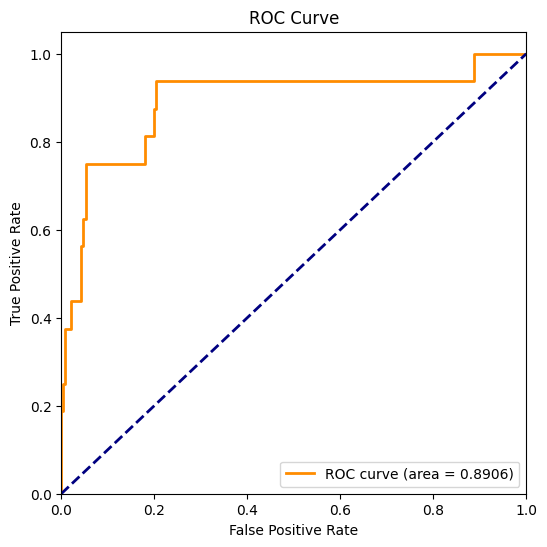

In [24]:
# =========================
# Cell 5: Evaluation Metrics (updated for stat+temporal inputs)
# =========================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

try:
    # Preferred: stat + seq inputs for both sides
    y_pred_prob = siamese_model.predict([X1_test_stat, X1_test_seq, X2_test_stat, X2_test_seq])
except Exception as e:
    print('Primary predict failed, attempting legacy inputs:', e)
    # fallback: attempt numeric-only inputs if available (may not match current model inputs)
    try:
        y_pred_prob = siamese_model.predict([X1_test_numeric, X2_test_numeric])
    except Exception as e2:
        raise RuntimeError('Prediction failed with both stat+seq and numeric-only inputs.\n' + str(e2)) from e2

y_pred = (y_pred_prob >= 0.5).astype(int).ravel()
y_true = np.asarray(y_test).ravel()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Classification report
print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))

# ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Confusion Matrix:
 [[235   5]
 [  4  12]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9833    0.9792    0.9812       240
           1     0.7059    0.7500    0.7273        16

    accuracy                         0.9648       256
   macro avg     0.8446    0.8646    0.8542       256
weighted avg     0.9659    0.9648    0.9653       256



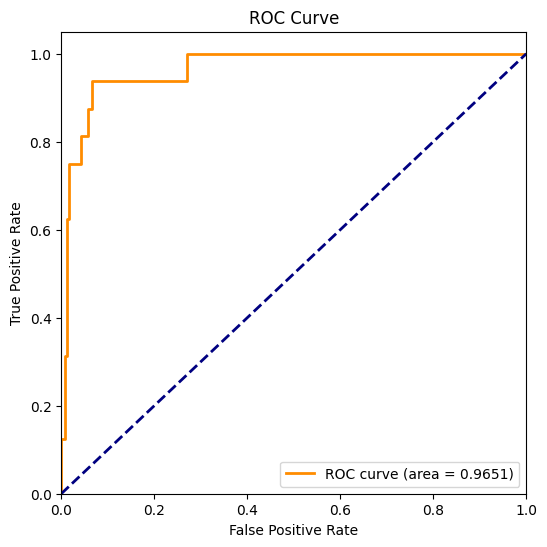

In [ ]:
# =========================
# Cell 5 (duplicate): Evaluation Metrics (updated for stat+temporal inputs)
# =========================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

try:
    y_pred_prob = siamese_model.predict([X1_test_stat, X1_test_seq, X2_test_stat, X2_test_seq])
except Exception as e:
    print('Primary predict failed, attempting legacy inputs:', e)
    try:
        y_pred_prob = siamese_model.predict([X1_test_numeric, X2_test_numeric])
    except Exception as e2:
        raise RuntimeError('Prediction failed with both stat+seq and numeric-only inputs.\n' + str(e2)) from e2

y_pred = (y_pred_prob >= 0.5).astype(int).ravel()
y_true = np.asarray(y_test).ravel()

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [95]:
siamese_model.save('siamese_model.keras')